Group 3: Photonic Boson Sampling in a Tunable Circuit

Members:
1. 23b1833
2. 22b1845
3. 23b1837
4. 23b1811
5. 23b1850

Work Distribution:

22b1845 - Understanding various complexities like #P-complete and NP-complete. Understanding fundamental structure of determinant and permanents, as well as the algortihms used to classically calculate them. Help in writing codes for reprodicing results.

23b1837 - Wrote code for helper functions and for plotting, used for reproducing results of papers. Helped writing the final report.

23b1833 - Derived how structure of permanents come in the physical process of boson sampling. Worked on understanding the theoretical part of the paper and helped derived results. Wrote the final report.

23b1811 - Worked on understanding the experimental part of the paper and derived all the relevent results. Helped in writing the final report.

23b1850 - Worked on deeply understanding the final results of the paper and understanding the implications of the results. Helped with the code for reproducing the results.


# 1. Introduction: The Extended Church-Turing Thesis and the Quantum Trilemma

Before exploring the specific experimental setup and calculations detailed in the paper, it is essential to understand the theoretical foundation that motivates this work. The paper addresses one of the most profound open questions at the intersection of physics, mathematics, and computer science: the validity of the Extended Church-Turing thesis.

### The Extended Church-Turing Thesis
The Extended Church-Turing thesis is a foundational tenet of computer science. It asserts that any computational function on a realistic physical device can be efficiently computed on a probabilistic Turing Machine. In simpler terms, it assumes that classical computers can efficiently simulate any physical process in the universe. 

### The Fundamental Trilemma
The very existence of Shor's factoring algorithm poses a fundamental trilemma, suggesting that at least one foundational tenet of physics, mathematics, or computer science must be untrue. Shor's algorithm states that efficient factoring of large composite numbers can be performed on a quantum computer, which is theoretically thought to be a realistic physical device. 

Because factoring is presumed to be computationally intractable for classical systems, we are left with three distinct possibilities:
1. **Physics breaks down:** A scalable quantum computer is not actually a realistic physical device, perhaps because quantum mechanics fails to hold for a large number of qubits.
2. **Mathematics/Complexity Theory is incomplete:** If scalable quantum computers are realistic, and the Extended Church-Turing thesis is correct, then a classical, efficient factoring algorithm must exist (which would break modern public-key cryptography like RSA).
3. **Computer Science must be revised:** The Extended Church-Turing thesis itself is fundamentally wrong.

Currently, there is no physical evidence that quantum mechanics breaks down at scale, nor is there any mathematical proof of an efficient classical factoring algorithm. This leaves the scientific community to critically examine the validity of the Extended Church-Turing thesis.

### Resolving the Trilemma 
To directly contradict the Extended Church-Turing thesis, one would need to build a physical device capable of efficiently performing a task that is strongly believed to be intractable for classical computers. 

While building a universal quantum computer capable of running Shor's algorithm at scale is technologically out of reach right now, this paper provides an alternative route. Rather than engineering a universal quantum machine, the authors experimentally perform a specific, highly non-classical scattering task. Scaling this particular task to large numbers of photons is a much simpler engineering challenge than building a universal quantum computer. If this specific task can be scaled up to a regime where classical verification is no longer possible, it will provide strong evidence against the Extended Church-Turing thesis, effectively resolving the trilemma.

## The Mathematical Core: Determinants vs. Permanents

To understand the specific task that challenges the Extended Church-Turing thesis, we first need to look at two closely related mathematical concepts: the determinant and the permanent of a matrix. 

### The Formulaic Similarity
For an $n \times n$ matrix $A$, the determinant is defined using the Leibniz formula, which sums over all possible permutations $\sigma$ of the symmetric group $S_n$:

$$Det(A) = \sum_{\sigma \in S_n} \text{sgn}(\sigma) \prod_{i=1}^n A_{i,\sigma(i)}$$

Here, $\text{sgn}(\sigma)$ is the sign of the permutation ($+1$ for even permutations, $-1$ for odd permutations). 

The **permanent** of a matrix has an almost identical definition, but it simply drops the alternating sign term:

$$Per(A) = \sum_{\sigma \in S_n} \prod_{i=1}^n A_{i,\sigma(i)}$$

Despite their striking visual similarity, this single change—dropping the permutation sign—results in a monumental shift in computational difficulty.

### The Complexity Chasm: Polynomial vs. Exponential
Because of the alternating sign, the determinant possesses geometric properties (like representing the signed volume of a parallelepiped) and algebraic symmetries. These properties allow us to use row operations (Gaussian elimination or LU decomposition) to calculate the determinant in **$O(n^3)$** time. It is a highly efficient, polynomial-time operation on classical computers.

The permanent, however, lacks these symmetries. You cannot use Gaussian elimination to find a permanent because adding a multiple of one row to another fundamentally changes the permanent's value. 
* A naive calculation using the definition requires summing over $n!$ permutations, which is $O(n!)$.
* Even the most efficient known exact algorithm (Ryser's algorithm) takes **$O(n 2^n)$** time. 

For large matrices, calculating the permanent scales exponentially, rapidly becoming intractable for classical computers. 

### Understanding the Intractability: NP vs. #P
To contextualize just how difficult calculating the permanent is, we can look at classical complexity classes:

* **NP (Nondeterministic Polynomial time):** This class contains decision problems (questions with a "yes" or "no" answer) where, if the answer is "yes", a proposed solution can be *verified* quickly (in polynomial time). For example, the Traveling Salesman Problem asks: *"Is there a route shorter than distance $X$?"* These are generally believed to be classically intractable to solve efficiently.
* **#P (Sharp-P):** This is the "counting" equivalent of NP. Instead of asking if a solution exists, it asks *how many* solutions exist. For example: *"How many valid Traveling Salesman routes are shorter than distance $X$?"*

Problems in #P are inherently harder than those in NP because you must count every valid state rather than just finding one. Calculating the permanent of a matrix is a **#P-complete** problem, meaning it is among the hardest problems in the #P class. If you could efficiently calculate the permanent, you could efficiently solve all NP problems and collapse the polynomial hierarchy.

<>:62: SyntaxWarning: invalid escape sequence '\m'
<>:63: SyntaxWarning: invalid escape sequence '\m'
<>:62: SyntaxWarning: invalid escape sequence '\m'
<>:63: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bruce\AppData\Local\Temp\ipykernel_5464\2309506937.py:62: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(sizes, det_times, marker='o', label='Determinant $\mathcal{O}(n^3)$', color='#007acc', linewidth=2)
C:\Users\bruce\AppData\Local\Temp\ipykernel_5464\2309506937.py:63: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(sizes, perm_times, marker='o', label='Permanent $\mathcal{O}(n!)$', color='#e63946', linewidth=2)


Running complexity benchmarks...
Size  2x2  | Det Time: 0.000563s | Perm Time: 0.000023s
Size  4x4  | Det Time: 0.000051s | Perm Time: 0.000047s
Size  5x5  | Det Time: 0.000025s | Perm Time: 0.000240s
Size  6x6  | Det Time: 0.000030s | Perm Time: 0.001540s
Size  8x8  | Det Time: 0.000037s | Perm Time: 0.085909s
Size 10x10 | Det Time: 0.000076s | Perm Time: 14.904048s


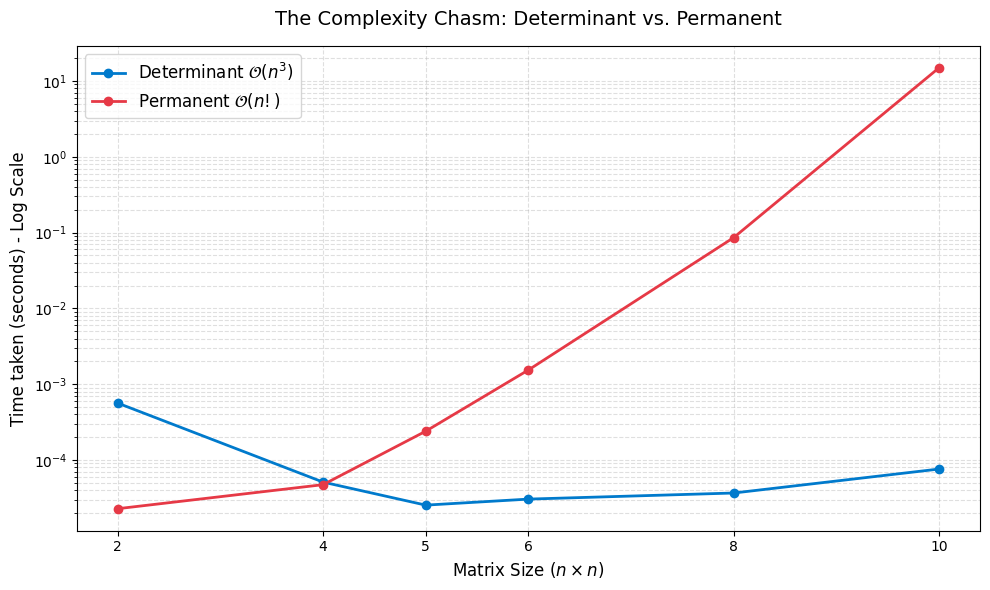

In [1]:
import numpy as np
import itertools
import time
from pathlib import Path
import matplotlib.pyplot as plt

PNG_OUTPUT_DIR = Path("png_plots")
PNG_OUTPUT_DIR.mkdir(exist_ok=True)

def calculate_permanent_naive(A):
    """
    Calculates the permanent of a matrix using the naive O(n!) definition.
    This directly mirrors the mathematical formula (summing over all permutations)
    without the alternating sign term used in determinants.
    """
    n = A.shape[0]
    perm = 0
    
    # Iterate over all possible permutations of the columns
    for p in itertools.permutations(range(n)):
        # Calculate the product of the elements for this specific permutation
        prod = 1
        for i in range(n):
            prod *= A[i, p[i]]
        perm += prod
        
    return perm

# Matrix sizes to benchmark
# Warning: Do not push this much past 10! 
# 10! = 3,628,800 permutations. 11! = 39,916,800 (will take a minute or two).
sizes = [2, 4, 5, 6, 8, 10]

det_times = []
perm_times = []

print("Running complexity benchmarks...")

for n in sizes:
    # Generate a random n x n matrix
    A = np.random.rand(n, n)
    
    # --- Benchmark Determinant ---
    start_det = time.perf_counter()
    np.linalg.det(A) # NumPy uses highly optimized O(n^3) algorithms
    end_det = time.perf_counter()
    det_times.append(end_det - start_det)
    
    # --- Benchmark Permanent ---
    start_perm = time.perf_counter()
    calculate_permanent_naive(A) # Our naive O(n!) implementation
    end_perm = time.perf_counter()
    perm_times.append(end_perm - start_perm)
    
    print(f"Size {n:>2}x{n:<2} | Det Time: {det_times[-1]:.6f}s | Perm Time: {perm_times[-1]:.6f}s")

# --- Plotting the Results ---
plt.figure(figsize=(10, 6))

# We use a logarithmic scale for the y-axis because the difference in time
# becomes so massive that a linear scale would squish the determinant line flat.
plt.plot(sizes, det_times, marker='o', label='Determinant $\mathcal{O}(n^3)$', color='#007acc', linewidth=2)
plt.plot(sizes, perm_times, marker='o', label='Permanent $\mathcal{O}(n!)$', color='#e63946', linewidth=2)

plt.yscale('log')
plt.xlabel('Matrix Size ($n \\times n$)', fontsize=12)
plt.ylabel('Time taken (seconds) - Log Scale', fontsize=12)
plt.title('The Complexity Chasm: Determinant vs. Permanent', fontsize=14, pad=15)
plt.xticks(sizes)
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(PNG_OUTPUT_DIR / "complexity_chasm_determinant_vs_permanent.png", dpi=220, bbox_inches="tight")

plt.show()


### The True Goal of the Experiment
It is important to clarify a crucial nuance: the goal of the experiment detailed in this paper is **not** to build a quantum machine that explicitly calculates and outputs the permanent of an arbitrary user-provided matrix. 

Instead, the paper focuses on simulating a specific physical process—the scattering of identical particles through a linear optical network. Quantum mechanics dictates that the probability amplitudes of these multi-particle scattering events are directly proportional to the permanents of various $n \times n$ sub-matrices. 

By physically running this experiment, the device naturally *samples* from this highly complex probability distribution. To simulate this exact same sampling process on a classical computer, one would have to calculate these #P-complete permanents over and over again. As the number of particles ($n$) grows, the classical simulation is choked by the exponential math, while the physical device generates the sample simply by letting the natural physics play out.

# 2. The Physics of Boson Sampling: Where the Permanent Arises

To understand why calculating the permanent is physically necessary, we must model our linear optical network using the framework of quantum mechanics. Specifically, we will look at how the physical properties of bosons dictate the underlying mathematics.

### 1. Defining the Input State
In quantum optics, we create a photon in a specific spatial mode $i$ by applying a creation operator $a_i^\dagger$ to the vacuum state $|0\rangle$. 

For simplicity, let's assume we inject exactly $n$ single photons into the first $n$ input ports of our $m$-mode linear optical network (where $n \le m$). The input Fock state $|S\rangle$ is mathematically written as the product of $n$ creation operators acting on the vacuum:

$$|S\rangle = a_1^\dagger a_2^\dagger \dots a_n^\dagger |0\rangle$$

### 2. The Unitary Evolution of the Network
When the photons pass through the linear optical circuit (which is made of beam splitters and phase shifters), the spatial modes are mixed. A photon entering mode $i$ has a probability amplitude $U_{i,j}$ of exiting at mode $j$.

Mathematically, the circuit applies a unitary transformation $U$ that evolves each input creation operator into a linear combination of output creation operators:

$$a_i^\dagger \rightarrow \sum_{j=1}^m U_{i,j} a_j^\dagger$$

### 3. The Output State
To find the state of the system after the photons have traversed the network, we substitute the unitary transformation into our initial state equation. The output state $|\psi_{\text{out}}\rangle$ becomes a massive product of sums:

$$|\psi_{\text{out}}\rangle = \left( \sum_{j_1=1}^m U_{1,j_1} a_{j_1}^\dagger \right) \left( \sum_{j_2=1}^m U_{2,j_2} a_{j_2}^\dagger \right) \dots \left( \sum_{j_n=1}^m U_{n,j_n} a_{j_n}^\dagger \right) |0\rangle$$

If you were to expand this product out completely, you would get $m^n$ terms, representing every conceivable way the $n$ photons could distribute themselves across the $m$ output modes.

### 4. Calculating the Probability Amplitude (The Permanent)
Now, suppose we place detectors at specific output modes and want to find the probability amplitude of detecting exactly one photon in specific target modes, say $k_1, k_2, \dots, k_n$. This specific target configuration is our output state $|T\rangle$:

$$|T\rangle = a_{k_1}^\dagger a_{k_2}^\dagger \dots a_{k_n}^\dagger |0\rangle$$

To find the probability amplitude for this specific scattering event, we need to calculate the inner product $\langle T | \psi_{\text{out}} \rangle$. In algebraic terms, we need to extract the coefficient in front of the specific term $a_{k_1}^\dagger a_{k_2}^\dagger \dots a_{k_n}^\dagger |0\rangle$ from the massive expanded polynomial in Step 3.

Here is where the physics of bosons dictates the math. **Because photons are bosons, their creation operators commute:**

$$[a_x^\dagger, a_y^\dagger] = a_x^\dagger a_y^\dagger - a_y^\dagger a_x^\dagger = 0$$

This means $a_x^\dagger a_y^\dagger = a_y^\dagger a_x^\dagger$. The order in which the photons are created at the detectors does not matter. 

Because the order doesn't matter, there are multiple ways to form the exact same target state $a_{k_1}^\dagger \dots a_{k_n}^\dagger$ when multiplying out the brackets. Specifically, a valid term is formed by picking one target mode from the first bracket, a different target mode from the second bracket, and so on. 

This means we must sum over every possible permutation $\sigma$ that maps the $n$ input photons to the $n$ target output modes. The coefficient we extract is the sum of the products of the transition amplitudes for every permutation:

$$\langle T | \psi_{\text{out}} \rangle = \sum_{\sigma \in S_n} U_{1, k_{\sigma(1)}} U_{2, k_{\sigma(2)}} \dots U_{n, k_{\sigma(n)}}$$

**This equation is the exact, formal definition of the permanent.** Specifically, it is the permanent of the $n \times n$ submatrix of $U$ formed by the $n$ input rows and the $n$ output columns. 

**The Conclusion:**
Because photons are indistinguishable bosons, quantum mechanics requires us to add the amplitudes of all possible paths they could take to reach the detectors. This summation perfectly mirrors the #P-complete calculation of the permanent. A classical computer chokes on this exponential sum, but the optical network computes it naturally through physical interference.

## The Fermionic Contrast: Anti-Commutation and the Determinant

A natural question arises: what if we performed this exact same experiment using identical fermions (like electrons) instead of identical bosons (photons)? 

If we swap the particle type, the underlying quantum physics fundamentally changes, and so does the computational complexity. 

### The Physics: Pauli Exclusion and Anti-Commutation
Fermions obey the Pauli Exclusion Principle, which dictates that no two identical fermions can occupy the exact same quantum state. Mathematically, this is expressed by the fact that fermionic creation operators **anti-commute**:

$$\{a_x^\dagger, a_y^\dagger\} = a_x^\dagger a_y^\dagger + a_y^\dagger a_x^\dagger = 0$$

This implies a crucial sign flip whenever we swap the order of two operators:

$$a_x^\dagger a_y^\dagger = -a_y^\dagger a_x^\dagger$$

### The Math: Alternating Signs and the Determinant
If we were to repeat the rigorous mathematical derivation from the previous section using fermions, we would still expand the massive polynomial of output states, and we would still sum over all permutations $\sigma$ of the particles routing to the target modes. 

However, because every pairwise swap of fermionic operators introduces a minus sign, the overall sign of any given term in our sum depends entirely on whether it takes an even or odd number of swaps to reach that permutation. We denote this parity as the sign of the permutation, $\text{sgn}(\sigma)$.

The resulting transition amplitude equation becomes:

$$\langle T | \psi_{\text{out}} \rangle = \sum_{\sigma \in S_n} \text{sgn}(\sigma) U_{1, k_{\sigma(1)}} U_{2, k_{\sigma(2)}} \dots U_{n, k_{\sigma(n)}}$$

**This equation is the exact, formal definition of the determinant.** Specifically, it is the determinant of the $n \times n$ submatrix of $U$.

### The Computational Conclusion: Fermions are "Easy"
As we demonstrated earlier in our Python benchmark, calculating the determinant is a highly efficient $O(n^3)$ process on a classical computer. 

Because the probability amplitudes for non-interacting fermions reduce to determinants, **"Fermion Sampling" can be efficiently simulated on a classical computer.** It does not challenge the Extended Church-Turing thesis. It is the unique, sign-free commutativity of bosons that forces the #P-complete permanent into existence, making Boson Sampling classically intractable and quantumly advantageous.

# 3. The Computational Race: Alice vs. Bob

To clearly illustrate the practical implications of Boson Sampling and the collapse of classical simulation, the authors of the paper frame the experiment as a race between two participants: Alice and Bob. 

They are both given the exact same task: given a specific unitary matrix $U$ (representing the linear optical circuit) and a specific input configuration of $n$ photons, they must generate a representative sample from the resulting probability distribution. The winner is whoever returns an accurate sample first.

### Alice: The Classical Contender
Alice represents the classical regime and the Extended Church-Turing thesis. She possesses only classical computing resources. 

To complete the task, Alice is given the mathematical description of the $m \times m$ unitary matrix $U$. She must use her classical computer to crunch the numbers, calculating the probability amplitudes for the various scattering events to build the sample distribution. As we established earlier, this requires her computer to explicitly calculate the #P-complete permanents of $n \times n$ sub-matrices. 

### Bob: The Quantum Contender
Bob represents the quantum regime. Instead of calculating the math, Bob possesses quantum physical resources. 

Bob builds (or programs) the actual linear-photonic network described by the unitary $U$. To get his sample, he doesn't calculate anything at all. He simply injects $n$ single photons into the physical circuit, allows them to interfere according to the laws of quantum mechanics, and records the output configurations using single-photon detectors. His "computation" is just letting the physics happen. 

### The Conjecture: Why Bob Ultimately Wins
For small numbers of photons ($n=2$ or $n=3$), this is a fair and verifiable race. Alice's classical computer can quickly calculate the permanents, generate a distribution, and verify that Bob's physical optical circuit is actually working correctly and producing the same distribution. This is exactly what the authors do in this paper: they use Alice's classical calculations to verify Bob's quantum experiment at a small, manageable scale.

However, the central conjecture of Boson Sampling is what happens as $n$ scales up. 

Because Alice's calculation time scales exponentially with $n$, her computation will quickly grind to a halt. The authors note that scaling to around $n=20$ or $n=30$ photons is where classical verification becomes practically impossible. At this scale, Bob will always win. While Alice waits millions of years for her computer to evaluate the permanents, Bob's photons pass through the optical circuit at the speed of light, generating the sample almost instantly. 

If Bob's device can be successfully scaled to this regime, it definitively proves that a physical device can efficiently perform a task that is intractable for classical computers, thereby providing strong evidence against the Extended Church-Turing thesis.

## The Prerequisite: Characterizing the Photonic Circuit

Before the computational race can officially begin, there is a major practical hurdle to overcome. Bob possesses the physical linear optical network—the intricate web of beam splitters and phase shifters. However, Alice needs the exact mathematical representation of that specific physical network (the $m \times m$ unitary matrix $U$) to perform her permanent calculations. 

How does Alice extract the exact mathematical matrix $U$ from Bob's physical hardware?

### The Traditional Bottleneck: Quantum Process Tomography
Historically, fully characterizing a quantum photonic circuit was done using a technique called Quantum Process Tomography. While effective, this method has a fatal flaw for large systems: the number of measurements required scales *exponentially* with the size of the system (the number of modes, $m$). 

If Alice had to perform an exponentially increasing number of measurements just to figure out what matrix she is supposed to be calculating, the race would be over before it even started. Her physical setup time would be just as intractable as her computational time.

### A Novel, Efficient Solution
To make this a fair and practical race, the authors use another novel characterization technique that is highly efficient. Instead of exponential scaling, this new method scales *linearly* with the number of modes. Specifically, it requires exactly $2m - 1$ distinct measurement combinations to fully map the matrix.

### The Classical Constraint: Using Coherent Light
There is one final rule to the race: Alice represents the classical regime. If she were forced to use single-photon sources and quantum non-classical interference to characterize the circuit, she would be "cheating" by utilizing Bob's quantum resources. 

Fortunately, this efficient $2m - 1$ method allows Alice to remain entirely classical. The technique relies solely on **single mode coherent states of light**. Coherent light—like the beam produced by a standard, macroscopic laser pointer—is a classical resource. 

By strategically shining classical laser light into the various input ports of the network and measuring the classical output intensities, Alice can fully synthesize the quantum unitary matrix $U$ without ever needing to generate or detect a single isolated photon. 

In the next section, we will **derive** exactly how Alice uses these $2m-1$ coherent light measurements to deduce both the amplitudes and the phases of the complete unitary matrix $U$.

## Characterizing the Unitary Matrix: The $2m-1$ Method

Before Alice can run her classical algorithm, she must synthesize the mathematical description of the linear optical network. 

Any linear photonic network can be described by a mapping between the input creation operators $a_i^\dagger$ and output creation operators $a_j^\dagger$:

$$a_j^\dagger = \sum_{i=1}^m U_{i,j} a_i^\dagger$$

The matrix $U$ is a complex $m \times m$ unitary matrix. Therefore, every individual matrix element can be written in polar form, containing both a magnitude $r$ and a phase $\theta$:

$$U_{ij} = r_{ij}e^{i\theta_{ij}}$$

To fully characterize $U$, Alice must find the magnitudes and relative phases for all elements. She can do this using entirely classical coherent states (laser light) in just $2m - 1$ steps.

### Step 1: Extracting Magnitudes ($m$ measurements)

First, Alice needs to find the magnitude, $r_{ij}$, for every element in the matrix $U$. To do this, she injects a single-mode coherent state (a classical laser beam) into one input mode $i$ at a time, leaving all other input ports completely dark. 

Let the complex electric field amplitude of the input laser at port $i$ be $E_i$. For mathematical simplicity, Alice calibrates her laser power such that the input intensity is normalized to $1$:

$$I_i^{\text{in}} = |E_i|^2 = 1$$

Because all other ports are dark, $E_k = 0$ for all $k \neq i$. 

We know from classical electrodynamics that a linear optical network transforms the input electric fields into output electric fields linearly according to the matrix $U$. The electric field at any output port $j$ is:

$$E_j^{\text{out}} = \sum_{k=1}^m U_{k,j} E_k^{\text{in}}$$

Because Alice only injected light into port $i$, every term in this sum is zero except for one. The equation collapses to:

$$E_j^{\text{out}} = U_{i,j} E_i$$

However, Alice's photodetectors at the output ports cannot measure the complex electric field directly; they measure classical intensity (which, in the quantum limit, corresponds to the average photon occupation number $n_{ij}$ at that port). Intensity is the absolute square of the electric field:

$$n_{ij} = |E_j^{\text{out}}|^2$$

Now, we substitute our collapsed electric field equation into the intensity equation:

$$n_{ij} = |U_{i,j} E_i|^2 = |U_{i,j}|^2 |E_i|^2$$

Recall that Alice normalized her input intensity ($|E_i|^2 = 1$), and that we defined the polar form of our matrix elements as $U_{i,j} = r_{ij}e^{i\theta_{ij}}$. The absolute square of the matrix element is simply the magnitude squared:

$$|U_{i,j}|^2 = r_{ij}^2$$

Substituting these back in leaves us with a direct equality:

$$n_{ij} = r_{ij}^2 (1)$$

Taking the square root of both sides gives Alice her final, observable relationship:

$$r_{ij} = \sqrt{n_{ij}}$$

**The Conclusion:**
By shining a laser into port $i$ and measuring the fractional intensity $n_{ij}$ arriving at port $j$, Alice directly measures the magnitude of the matrix element $U_{i,j}$. To find the magnitudes of the entire $m \times m$ matrix, she simply repeats this process, moving the input laser to each of the $m$ ports one by one. This takes exactly **$m$ measurements**.

### Step 2: Extracting Phases ($m-1$ measurements)
Finding the phases is trickier, as phase cannot be measured directly; it must be inferred from interference. To do this, Alice selects one input port (let's say port $1$) to act as her constant phase reference. 

She then injects coherent light into **two input modes simultaneously**: the reference port $1$ and another target port $k$. She controls the input fields such that port $1$ has a constant phase, and port $k$ has an adjustable phase shift $\phi$:

$$E_1 = 1, \quad E_k = e^{i\phi}$$

From the linear properties of the network, the electric field at any output mode $j$ is the superposition of these two inputs:

$$E_j = U_{1j}E_1 + U_{kj}E_k$$

Substituting our input fields:

$$E_j = U_{1j} + U_{kj}e^{i\phi}$$

Alice's detectors measure the output intensity $I_j$, which is the absolute square of the electric field:

$$I_j = |E_j|^2 = |U_{1j} + U_{kj}e^{i\phi}|^2$$

Expanding this out, we get a cross-term that represents the interference:

$$I_j = |U_{1j}|^2 + |U_{kj}|^2 + 2 \text{Re} \left( U_{1j}^* U_{kj} e^{i\phi} \right)$$

Now, we substitute the polar forms of our matrix elements ($U = re^{i\theta}$) back into the equation:

$$I_j = r_{1j}^2 + r_{kj}^2 + 2r_{1j}r_{kj} \cos(\phi + \Delta\theta)$$

where $\Delta\theta = \theta_{kj} - \theta_{1j}$ is the relative phase difference between the two paths.

**The Physics in the Math:**
Because Alice is constantly varying (scanning) her input phase shift $\phi$, the output intensity $I_j$ will oscillate, producing a sinusoidal interference fringe. By simply looking at the phase offset of this measured wave, Alice instantly knows $\Delta\theta$. 

Because she already found the magnitudes ($r$) in Step 1, this interference pattern gives her the exact relative phases. She pairs her reference port $1$ with every other port $k \in \{2, \dots, m\}$, which requires exactly **$m - 1$ measurements**.

### The Conclusion
By combining the two steps, Alice has fully reconstructed the $m \times m$ unitary matrix $U$ using exactly **$2m - 1$ measurements**. She has completely bypassed the exponential scaling of quantum process tomography and is now ready to compute the permanents for the race!

## Alice's Calculation: Constructing the Submatrix $U_{ST}$

Now that Alice has successfully characterized the full $m \times m$ unitary matrix $U$ using her classical laser light, she is ready to calculate the probabilities of specific scattering events. 

To do this, she needs to translate her specific $m$-mode input and output configurations into a condensed $n \times n$ matrix that only contains the relevant transition amplitudes for the $n$ photons.

### The Theory: Why We Reduce the Matrix
Recall from our derivation of the permanent that the probability amplitude involves summing over all possible paths the $n$ input photons could take to reach the $n$ target output modes. 

Let the input configuration be $S = (s_1, \dots, s_m)$, where $s_i$ is the number of photons in mode $i$. 
Let the output configuration be $T = (t_1, \dots, t_m)$, where $t_j$ is the number of photons measured in mode $j$. 
The total number of photons is $\sum s_i = \sum t_j = n$.

The full matrix $U$ contains information about *every* mode, including the empty ones. To calculate the permanent, Alice must strip away the irrelevant empty modes and duplicate the modes that contain multiple photons. She does this in two steps to build the submatrix $U_{ST}$:
1. **Filter Outputs (Create $U_T$):** She takes $t_j$ copies of the $j$-th column of $U$. This represents the destination of the photons.
2. **Filter Inputs (Create $U_{ST}$):** From $U_T$, she takes $s_i$ copies of the $i$-th row. This represents the origin of the photons.

The resulting matrix $U_{ST}$ is an $n \times n$ matrix. Every element $u_{xy}$ inside this matrix represents the direct transition amplitude of one specific input photon reaching one specific output detector. Taking the permanent of this matrix perfectly executes the summation over all possible path permutations we derived earlier.

### A Concrete Example
Let's look at exactly how Alice builds this matrix. 

Suppose we have a network with $m = 4$ modes, and we are injecting $n = 3$ photons. 
Let Alice's characterized unitary matrix $U$ be:

$$U = \begin{pmatrix} u_{11} & u_{12} & u_{13} & u_{14} \\ u_{21} & u_{22} & u_{23} & u_{24} \\ u_{31} & u_{32} & u_{33} & u_{34} \\ u_{41} & u_{42} & u_{43} & u_{44} \end{pmatrix}$$

**Step 1: Define Configurations**
Assume we inject one photon into modes 1, 3, and 4. 
Our input configuration is $S = (1, 0, 1, 1)$.

Assume we want to calculate the probability of detecting one photon in modes 2, 3, and 4. 
Our target output configuration is $T = (0, 1, 1, 1)$.

**Step 2: Build $U_T$ (Columns)**
Looking at $T$, we have 0 photons in mode 1, and 1 photon in modes 2, 3, and 4. Alice drops the first column and keeps columns 2, 3, and 4.

$$U_T = \begin{pmatrix} u_{12} & u_{13} & u_{14} \\ u_{22} & u_{23} & u_{24} \\ u_{32} & u_{33} & u_{34} \\ u_{42} & u_{43} & u_{44} \end{pmatrix}$$

**Step 3: Build $U_{ST}$ (Rows)**
Looking at $S$, we have 0 photons in mode 2, and 1 photon in modes 1, 3, and 4. Alice drops the second row from $U_T$ and keeps rows 1, 3, and 4.

$$U_{ST} = \begin{pmatrix} u_{12} & u_{13} & u_{14} \\ u_{32} & u_{33} & u_{34} \\ u_{42} & u_{43} & u_{44} \end{pmatrix}$$

We are left with a neat $3 \times 3$ matrix containing only the relevant quantum pathways!

### Quantum vs. Classical Probabilities
With $U_{ST}$ in hand, Alice can now calculate two different probabilities depending on the rules of the physics involved.

**1. The Quantum Case (Indistinguishable Photons)**
If the photons are perfectly identical (same wavelength, polarization, and arrival time), they exhibit pure quantum interference. The total amplitude is the sum of the complex path amplitudes, which we then square to get the probability:

$$P_T^Q = |\text{Per}(U_{ST})|^2$$

**2. The Classical Case (Distinguishable Photons)**
If the photons are distinguishable in any way (for example, if Bob introduces a slight time delay between them so they arrive at the beam splitters at slightly different moments), quantum interference breaks down. 

Instead of adding the complex amplitudes and *then* squaring, classical physics dictates that we must square the absolute value of each individual matrix element *first* to find individual path probabilities, and then sum those probabilities. 

Alice does this by creating a new matrix $\tilde{U}_{ST}$, where every element is the absolute square of the elements in $U_{ST}$ ($\tilde{U}_{ST_{ij}} = |U_{ST_{ij}}|^2$). The classical probability is simply the permanent of this new matrix:

$$P_T^C = \text{Per}(\tilde{U}_{ST})$$

*(Note: Because $\tilde{U}_{ST}$ contains only positive real numbers, calculating its permanent is actually much easier for a classical computer using approximation algorithms, further highlighting how the quantum interference of complex numbers drives the #P-complete intractability.)*

## Reproducing the $U_{ST}$ calculation results:

Below is the code to reprodice the result given in the paper, where an explicit calculation is show to find the reduced 2 $\times$ 2 matrix $U_{ST}$ from the starting unitary $U$ given below:

$$
U_{\mathrm{exp}}^{(2\text{photon})} =
\begin{pmatrix}
0.297 & 0.325 + 0.000i & 0.126 + 0.000i & 0.500 + 0.000i & 0.430 + 0.000i & 0.253 + 0.000i \\
0.330 & -0.302 - 0.011i & 0.001 + 0.503i & 0.028 - 0.390i & 0.221 + 0.118i & -0.385 - 0.213i \\
0.388 & 0.182 + 0.248i & -0.220 + 0.133i & -0.212 + 0.204i & -0.127 - 0.386i & 0.108 - 0.081i \\
0.311 & -0.220 - 0.315i & -0.169 - 0.246i & 0.190 + 0.157i & -0.073 - 0.089i & -0.227 + 0.355i \\
0.396 & -0.222 - 0.169i & 0.387 - 0.130i & -0.265 + 0.004i & -0.103 + 0.202i & 0.353 - 0.112i \\
0.279 & 0.322 + 0.244i & -0.101 - 0.239i & -0.051 - 0.400i & -0.184 + 0.320i & -0.217 + 0.074i
\end{pmatrix}
$$

Given the input mode was $S = (1 0 1 0 0 0)$ and the output mode to be measured was $T = (010010)$

In [2]:
import numpy as np
from itertools import permutations

# -----------------------------
# 1) Experimental 6x6 unitary
# -----------------------------
U_exp_2photon = np.array([
    [0.297+0.000j,  0.325+0.000j,  0.126+0.000j,  0.500+0.000j,  0.430+0.000j,  0.253+0.000j],
    [0.330+0.000j, -0.302-0.011j,  0.001+0.503j,  0.028-0.390j,  0.221+0.118j, -0.385-0.213j],
    [0.388+0.000j,  0.182+0.248j, -0.220+0.133j, -0.212+0.204j, -0.127-0.386j,  0.108-0.081j],
    [0.311+0.000j, -0.220-0.315j, -0.169-0.246j,  0.190+0.157j, -0.073-0.089j, -0.227-0.355j],
    [0.396+0.000j, -0.222-0.169j,  0.387-0.130j, -0.265+0.004j, -0.103+0.202j,  0.353-0.112j],
    [0.279+0.000j,  0.322+0.244j, -0.101-0.239j, -0.051-0.400j, -0.184+0.320j, -0.217+0.074j],
], dtype=complex)

# -----------------------------
# 2) Occupation vectors
#    We follow the matrices shown in the paper.
#    Input modes: 1 and 3
#    Output modes: 2 and 5
# -----------------------------
S = np.array([1, 0, 1, 0, 0, 0], dtype=int)  # input occupation
T = np.array([0, 1, 0, 0, 1, 0], dtype=int)  # output occupation

def occupation_to_indices(occ):
    """Convert occupation vector into repeated indices."""
    occ = np.asarray(occ, dtype=int)
    return np.repeat(np.arange(len(occ)), occ)

input_rows = occupation_to_indices(S)
output_cols = occupation_to_indices(T)

# -----------------------------
# 3) Build U_T and U_ST
# -----------------------------
U_T = U_exp_2photon[:, output_cols]
U_ST = U_T[input_rows, :]

print("U_T =")
print(U_T)
print("\nU_ST =")
print(U_ST)

# -----------------------------
# 4) Permanent function
# -----------------------------
def permanent(A):
    A = np.asarray(A, dtype=complex)
    n, m = A.shape
    if n != m:
        raise ValueError("Permanent is defined here for square matrices only.")
    total = 0.0 + 0.0j
    for p in permutations(range(n)):
        prod = 1.0 + 0.0j
        for i, j in enumerate(p):
            prod *= A[i, j]
        total += prod
    return total

# -----------------------------
# 5) Probabilities
# -----------------------------
per_U_ST = permanent(U_ST)
P_Q = abs(per_U_ST)**2

P_C = permanent(np.abs(U_ST)**2).real

print("\nPermanent(U_ST) =", per_U_ST)
print("P_T^Q =", P_Q)
print("P_T^C =", P_C)

U_T =
[[ 0.325+0.j     0.43 +0.j   ]
 [-0.302-0.011j  0.221+0.118j]
 [ 0.182+0.248j -0.127-0.386j]
 [-0.22 -0.315j -0.073-0.089j]
 [-0.222-0.169j -0.103+0.202j]
 [ 0.322+0.244j -0.184+0.32j ]]

U_ST =
[[ 0.325+0.j     0.43 +0.j   ]
 [ 0.182+0.248j -0.127-0.386j]]

Permanent(U_ST) = (0.036985-0.018810000000000007j)
P_T^Q = 0.0017217063250000002
P_T^C = 0.034938045325


### Expected numerical result

For the matrix shown in the paper, the calculation gives

$$
\mathrm{Per}(U_{ST}) \approx 0.036985 - 0.018810\, i,
$$

so

$$
P_T^{Q} = \left|\mathrm{Per}(U_{ST})\right|^2 \approx 0.0017.
$$

For the distinguishable-photon case,

$$
P_T^{C} = \mathrm{Per}(\tilde U_{ST}) \approx 0.0349.
$$

These match the values reported in the paper.

## Bob's Execution: The Quantum Challenger Setup

While Alice is forced to build matrices and calculate complex permanents on her classical machine, Bob takes the physical route. His task is to experimentally prepare the $n$-photon Fock state $|t_1, \dots, t_m\rangle$, inject it into the circuit, and measure the output. 

Here is exactly how Bob sets up the hardware for this Boson Sampling demonstration.

### 1. The Photon Generation Stage (The Source)

The experiment relies on indistinguishable single photons. The generation of these photons involves a carefully calibrated chain of nonlinear optical components.

The Ti:Sapphire (Ti:S) Laser

What it is: A mode-locked Titanium-Sapphire laser operating at a high repetition rate (~80 MHz).

Why it is chosen: 1. Timing (Femtosecond Pulses): It generates ultrashort pulses (~100–200 fs). This extremely short pulse duration provides a sharp "clock" timestamp for photon creation, ensuring the resulting photons have narrow wavepackets. This is absolutely critical to make them overlap perfectly at the interference stage.
2. High Repetition Rate: Multi-photon coincidence events (getting 3 specific photons to the end of the circuit simultaneously) are extremely rare due to inherently low conversion efficiencies and circuit losses. An ~80 MHz rate provides 80 million "trials" per second, which is necessary to gather statistically significant data in a reasonable timeframe.

Role: It acts as the primary pump source, emitting high-intensity near-infrared light (~820 nm).

Second Harmonic Generation (SHG) using LBO

What it does: The SHG stage takes the 820 nm infrared photons from the Ti:S laser and uses a non-linear process to combine pairs of them, creating single photons with double the energy (and half the wavelength).

The LBO Crystal (Lithium Triborate): In high-power ultrafast setups like this, LBO is heavily favored for the SHG stage.

Physics of LBO: It is a birefringent crystal with a high optical damage threshold and a broad transparency range. It utilizes its $\chi^{(2)}$ (second-order nonlinear) susceptibility. When the intense 820 nm laser field enters the LBO lattice, the anharmonic response of the electrons causes two 820 nm photons to annihilate and spontaneously generate a single 410 nm photon.

Phase Matching: To make this efficient, the LBO crystal must be cut at a precise angle or temperature-tuned (often non-critical phase matching) so that the refractive index for the 820 nm pump matches the refractive index for the 410 nm second harmonic. This ensures the newly generated blue light interferes constructively as it travels through the crystal.

Why it is used: To drive the next down-conversion stage efficiently to produce photons in the measurable near-infrared spectrum, the pump must be in the ultraviolet/blue range. The SHG LBO outputs a beam of ~410 nm pulsed light.

Spontaneous Parametric Down-Conversion (BBO)

What it does: The 410 nm UV pulses pump nonlinear Beta Barium Borate (BBO) crystals. Through SPDC, a single high-energy UV pump photon probabilistically splits into a pair of lower-energy photons (two ~820 nm photons) called the signal and idler.

Why it is used: SPDC is the standard method for producing heralded single photons. Because energy ($\omega_{pump} = \omega_{signal} + \omega_{idler}$) and momentum ($\vec{k}_{pump} = \vec{k}_{signal} + \vec{k}_{idler}$) are strictly conserved, the photons are emitted in correlated pairs at specific spatial angles.

Triggering: The experiment uses two BBO crystals to generate two pairs (4 photons total). One photon is immediately routed to an Avalanche Photodiode (APD) to act as a trigger. Detecting this photon collapses the wavefunction, "heralding" the guaranteed presence of its partner, which is then injected into the circuit alongside the other pair.

### 2. Injection, Indistinguishability, and the Physics of Time Delay ($\Delta\tau$)

In the schematic, delay lines ($\Delta\tau_1, \Delta\tau_3$) are present on paths 1 and 3 before they enter the main circuit.

The Physical Mechanism of Delay Lines

How is "time" actually delayed in a photonics lab? Since photons always travel at the speed of light $c$ (in a given medium), the only way to delay a photon is to make it travel a longer physical distance.

The Hardware: A delay line typically consists of a retroreflector (a prism or a pair of mirrors) mounted on a highly precise, motorized translation stage.

The Math: If the motorized stage moves backwards by a physical distance $\Delta x$, the optical path length the photon must travel increases by $2\Delta x$ (since the light goes out to the mirror and comes back). The time delay introduced is perfectly mapped to physical distance: $\Delta\tau = \frac{2\Delta x}{c_{fiber}}$. By moving the stage in micrometer steps, researchers can delay the photon by femtoseconds.

The Critical Role of Coherence Length ($L$)

Quantum interference (the Hong-Ou-Mandel effect) only occurs if the photons are fundamentally indistinguishable. If a photon is delayed by a time significantly longer than its coherence length $L$ (i.e., $\Delta\tau \gg L$), their temporal wavepackets do not overlap in the central tritter. If this happens, the universe can "tell them apart" by their arrival time. They lose their quantum interference properties and behave like classical, distinguishable billiard balls.

The Solution: By sweeping the motorized stage and monitoring the coincidence counts, the researchers find the exact position where the wavepackets overlap in time ($\Delta\tau = 0$), erasing any timing information and restoring quantum indistinguishability.

The Challenge of Scaling from $n=2$ to $n=3$

$n=2$ monitoring: For two-photon inputs, researchers can continuously scan the delay line to map out the "Hong-Ou-Mandel dip" (a drop in coincidence counts proving interference).

$n=3$ scaling problem: For three injected photons (plus one trigger), the raw coincidence count rate is extremely low. A continuous delay scan is impossible because environmental drift (temperature changes expanding fibers, laser drift) would ruin the alignment before the scan finishes. Thus, precisely known, static calibration points must be used.

### 3. Mode Mapping and the Core Circuit

The experiment mathematically implements a $6 \times 6$ fully connected unitary matrix $U$, but physically uses only 3 spatial fibers. It achieves the dimension of 6 by multiplexing polarization.

Spatial Modes ($k$): $1, 2, 3$ (The physical fibers).

Polarization Modes ($p$): $|H\rangle$ (Horizontal), $|V\rangle$ (Vertical).

Logical Mode Mapping ($m$): $m \in \{1, 2, 3, 4, 5, 6\} \equiv \{|H\rangle_1, |V\rangle_1, |H\rangle_2, |V\rangle_2, |H\rangle_3, |V\rangle_3\}$.

#### 3.1 How the Central Tritter (FBS) Actually Works

The heart of the spatial interference is the $3 \times 3$ Fused-Fibre Beam-Splitter (FBS). This is not a standard mirror-based beam-splitter; it is an integrated waveguide component that relies on the wave-nature of light.

The Fabrication: Three separate standard optical fibers (each with a core and cladding) are stripped of their protective coatings. They are tightly twisted together, heated with a precise flame until the glass softens, and gently pulled. This tapering process causes the fiber cores to become incredibly thin and merge close together over a specific interaction region.

The Physics: Evanescent Wave Coupling: Light is an electromagnetic wave. While most of the light's energy is confined within the silica fiber core by total internal reflection, the boundary is not perfectly sharp. A small portion of the electromagnetic field—called the evanescent wave—exponentially decays and "leaks" outside the core into the cladding.

The Interference: In the fused taper region, the cores are so close together that the evanescent wave of a photon in Fiber 1 reaches into the cores of Fiber 2 and Fiber 3. This allows the photon to quantum-mechanically "tunnel" or couple between the fibers.

The Result ($u^{(3)}$): By precisely controlling the heat, pull tension, and interaction length during manufacturing, the engineers create a symmetric device where light entering any single input core will smoothly oscillate between the three cores, exiting with a perfect 33.3% probability in each output fiber. Because it is made of standard fiber glass, it is non-polarising—it performs this spatial mixing identically for both Horizontal and Vertical polarizations.


### 4. Mathematical Evolution of a 3-Photon State (Example)

Let's trace a specific state with $n=3$ indistinguishable photons through the setup using creation operators $\hat{c}_{k,p}^\dagger$.

Step 0: Initial State

$$
|\psi_{in}\rangle = \hat{c}_{1,H}^\dagger(t + \Delta\tau_1) \hat{c}_{2,H}^\dagger(t) \hat{c}_{3,H}^\dagger(t + \Delta\tau_3) |0\rangle
$$

Assuming perfect experimental tuning ($\Delta\tau_1 = 0, \Delta\tau_3 = 0$), the time dependence becomes uniform. We can drop the time variables and write the operators simply as $\hat{c}_{k,H}^\dagger$.

Step 1: Input Local Unitaries (Polarization Controllers $a_1, a_2, a_3$)

$$
a_k = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & -1 \\ 1 & 1 \end{pmatrix}
$$

Transformation: $\hat{c}_{k,H}^\dagger \xrightarrow{a_k} \frac{1}{\sqrt{2}} (\hat{c}_{k,H}^\dagger + \hat{c}_{k,V}^\dagger)$

Step 2: The Central Tritter ($u^{(3)}$ FBS)

$$
u^{(3)} = \frac{1}{\sqrt{3}} \begin{pmatrix} 1 & 1 & 1 \\ 1 & e^{i2\pi/3} & e^{-i2\pi/3} \\ 1 & e^{-i2\pi/3} & e^{i2\pi/3} \end{pmatrix}
$$

Transformation: $\hat{c}_{k,p}^\dagger \xrightarrow{u^{(3)}} \sum_{j=1}^{3} u_{j,k}^{(3)} \hat{c}_{j,p}^\dagger$

Step 3: Output Local Unitaries (POL $b_1, b_2, b_3$)

$$
b_j = \begin{pmatrix} \gamma_j & \delta_j \\ -\delta_j^* & \gamma_j^* \end{pmatrix}
$$

Transformation: $\hat{c}_{j,H}^\dagger \xrightarrow{b_j} \gamma_j \hat{d}_{j,H}^\dagger + \delta_j \hat{d}_{j,V}^\dagger$

Step 4: Separation (PBS) and Final Output

$$
\hat{c}_i^\dagger \xrightarrow{U} \sum_{m=1}^{6} U_{m,i} \hat{d}_{m}^\dagger
$$

$$
|\psi_{final}\rangle = \left( \sum_{m=1}^{6} U_{m,1} \hat{d}_{m}^\dagger \right) \left( \sum_{m=1}^{6} U_{m,3} \hat{d}_{m}^\dagger \right) \left( \sum_{m=1}^{6} U_{m,5} \hat{d}_{m}^\dagger \right) |0\rangle
$$

### 5. Supplementary Part

A. Non-Ideal Photon Sources (Higher-Order Emissions)

$$
|\psi\rangle \propto |00\rangle + \eta|11\rangle + \eta^2|22\rangle + \eta^3|33\rangle + ...
$$

B. Partial Distinguishability

The Problem: Independent BBO sources never produce perfectly identical photons. Mismatches in frequency spectrum or spatial fiber coupling mean photons are partially distinguishable.

The Fix: Partial distinguishability prevents the experimental visibility ($V$) from ever reaching a perfect 1.0. The mathematical models are adjusted to interpolate smoothly between the purely quantum Permanent ($P_T^Q$) and the purely classical Distinguishable Permanent ($P_T^C$) to account for this inherent physical mismatch.

C. Photon Loss

The Problem: Integrated photonic circuits suffer from optical scattering, and APDs only have ~30-50% detection efficiency. Most injected 3-photon states are lost.

The Fix (Post-Selection): The system records data only when exactly 3 independent detectors click simultaneously. Crucially, linear uniform loss does not change the mathematical complexity of the permanent. It acts as a uniform scaling factor. While loss makes data collection exponentially slower, the successful post-selected samples still accurately reflect the #P-hard BosonSampling distribution.

## The Measurement Problem: Why Raw Probabilities Fail

At first glance, verifying the results of the race seems simple: Bob runs his experiment, counts the number of times he sees a specific output configuration $T$, divides by the total number of runs to get a raw probability, and compares it to Alice's calculated quantum probability $P_T^Q$. 

However, in the real world, this approach completely fails. The problem lies in Bob's hardware. 

### The Flaw: Unequal Detector Efficiencies
Bob uses single-photon avalanche diodes to detect the photons. These detectors are highly sensitive, but they are not identical; each detector has a slightly different detection efficiency, $\eta_j$. 

If Bob is looking for a specific output configuration $T = (t_1, t_2, \dots, t_m)$, the actual measured coincidence count $M_T$ is skewed by the specific detectors involved in that event. 

Mathematically, the measured signal is proportional to the true theoretical probability $P_T$ multiplied by an overarching efficiency factor $\eta_T$ for that specific configuration:

$$M_T \propto \eta_T P_T$$

where $\eta_T = \prod_{j=1}^m (\eta_j)^{t_j}$.

Because $\eta_T$ varies depending on which specific output ports are triggered, Bob cannot simply normalize his raw counts across all possible permutations. The skewed efficiencies make a direct comparison to Alice's pure mathematical probabilities impossible.

### The Solution: Non-Classical Interference Visibility
To create a fair, hardware-agnostic comparison, the authors use a metric called **non-classical interference visibility ($V_T$)**. 

Visibility is a normalized measure that compares the quantum scattering probability against the classical (distinguishable) scattering probability. It is defined as:

$$V_T = \frac{P_T^C - P_T^Q}{P_T^C}$$

Here, $P_T^Q$ is the quantum probability (indistinguishable photons), and $P_T^C$ is the classical probability (distinguishable photons).

### The Mathematical Proof: Canceling the Hardware
Why does visibility solve Bob's problem? Let's substitute Bob's actual measured signals into the visibility equation. 

Bob measures the raw quantum signal $M_T^Q$ and the raw classical signal $M_T^C$. Because both measurements are looking at the exact same output configuration $T$, they suffer from the *exact same* detector efficiency penalty $\eta_T$:

$$M_T^Q = \eta_T P_T^Q$$
$$M_T^C = \eta_T P_T^C$$

If Bob calculates the visibility using his raw measured data, the efficiency factor completely factors out:

$$V_T^{\text{Bob}} = \frac{M_T^C - M_T^Q}{M_T^C} = \frac{\eta_T P_T^C - \eta_T P_T^Q}{\eta_T P_T^C} = \frac{\eta_T (P_T^C - P_T^Q)}{\eta_T (P_T^C)} = \frac{P_T^C - P_T^Q}{P_T^C}$$

By measuring both the quantum and classical states and finding their relative difference, the hardware imperfections perfectly cancel out! 

### How Bob and Alice Obtain $P_T^C$
To use this metric, both competitors must be able to produce the classical probability $P_T^C$ for the target event.

**Bob's Experimental Method:**
To strip away the quantum interference and measure the classical probability, Bob introduces a temporal delay ($\Delta\tau$) between the input photons before they enter the circuit. If he delays the photons so that the time gap between them is significantly larger than their coherence length ($L$), the photons become physically distinguishable by their arrival times. True multi-photon quantum interference cannot occur, and the output statistics naturally degrade to the classical probability $P_T^C$. He efficiently samples this just by running his delayed circuit.

**Alice's Computational Method:**
As we established in the previous section, Alice already knows how to calculate this. She takes her reduced submatrix $U_{ST}$, creates the new matrix $\tilde{U}_{ST}$ by taking the absolute square of every element, and calculates its permanent.

With both Alice and Bob calculating the same, hardware-independent visibility metric $V_T$, the race can finally be judged fairly.

### A Practical Hurdle: The Low Count Rate Problem for $n=3$

While finding the classical probability $P_T^C$ by introducing a time delay sounds straightforward in theory, executing it physically introduces a new set of challenges as the number of photons increases. 

**The Problem: System Drift over Long Runtimes**
For the $n=2$ photon case, Bob can easily monitor the output configuration continuously while slowly scanning the temporal delay between the two input photons. This produces a clear, continuous transition curve between the quantum and classical regimes (similar to a standard Hong-Ou-Mandel dip). 

However, moving to $n=3$ photons drastically lowers the coincident count rates (specifically, the four-photon count rate, since one photon is used as a trigger). Because the events are so rare, scanning the delay continuously would take an incredibly long time. Over these extended experimental runtimes, inevitable physical issues like optical misalignment and thermal drift would severely degrade the accuracy of the measurements.

**The Solution: Discrete Extreme Measurements**
To combat this, the authors abandon the continuous scan for $n=3$ and instead rely on a minimal set of discrete measurement points. 

To find the quantum probability $P_T^Q$, Bob only needs a **single measurement** where all three photons arrive simultaneously. This is achieved by setting the temporal delays of the first and third photons relative to the second photon to zero: $\{0, 0, 0\}$.

To find the classical probability $P_T^C$, Bob shifts the photons so far apart that they are completely distinguishable (a delay $\Delta\tau_\infty$ that is much larger than their coherence length). To account for any asymmetric optical misalignment that might occur, he takes **just two measurement settings** at the extreme ends of the delay spectrum and averages them:
1. Photon 1 is early, Photon 3 is late: $\{-\Delta\tau_\infty, 0, \Delta\tau_\infty\}$
2. Photon 1 is late, Photon 3 is early: $\{\Delta\tau_\infty, 0, -\Delta\tau_\infty\}$

By calculating $P_T^C$ as the average of these two extreme classical probabilities, Bob successfully minimizes the effect of system drift and misalignment without needing to run an impractically long continuous scan.

# Three-Photon Boson Sampling with Colliding Outputs

## Figure Description

**FIG. 4:** Three-photon BosonSampling with colliding outputs.

- **(a)** Experimental setup illustrating number-resolving detection using a 50:50 fiber beam splitter at the output of mode 5 along with an additional single-photon detector.  
- **(b)** Comparison between theoretical predictions and experimental measurements of visibility for different output configurations.

---

## Detailed Explanation

## (a) Experimental Setup — Key Focus

### 1. Purpose of the Setup

The setup is designed to perform **BosonSampling with three photons**, where multiple photons can exit through the **same output mode (collisions)**. Detecting such events requires distinguishing between one and more photons in a single mode.

---

### 2. Optical Circuit

The left side of the figure shows a **fiber-based linear optical network**, where:

- Photons are injected into **input modes 1, 3, and 5**
- The network consists of:
  - Beam splitters
  - Fiber connections
- These elements collectively implement a **unitary transformation** on the input photons

As photons propagate through the network, they undergo **multi-path quantum interference**, which determines the final output distribution.

---

### 3. The Detection Problem

Standard detectors (APDs):
- Only detect the **presence of photons**
- Cannot distinguish:
  - 1 photon vs 2 photons

However, in this experiment, outputs like:
- $(1,5,5)$  
require detecting **two photons in the same mode (mode 5)**

---

### 4. Number-Resolving Detection Using a 50:50 Beam Splitter

To solve this, the setup introduces a **50:50 fiber beam splitter (BS)** at output mode 5.

#### How it works:

- If a single photon arrives:
  - It randomly goes to one of the two detectors

- If two photons arrive:
  - They can split and reach **both detectors simultaneously**

#### Key Idea:
- **Coincidence detection (both detectors click)** → indicates **two photons were present**

This effectively converts:
$$
\text{Non-number-resolving detectors} \rightarrow \text{Effective number-resolving system}
$$

---

### 5. Role of the Additional Detector

- The extra detector placed after the beam splitter enables:
  - Detection of **simultaneous clicks**
  - Identification of **multi-photon events**

Without this, collision events would be indistinguishable from single-photon events.

---

### 6. Imperfect Beam Splitter

The caption notes:

> An imperfect splitting ratio only affects efficiency

This means:
- If the beam splitter is not exactly 50:50:
  - Some two-photon events may not split correctly
- However:
  - The **underlying physics and interference remain unchanged**
  - Only the **detection rate** is affected

---

### 7. Summary of (a)

The experimental setup demonstrates:

- Implementation of a **3-photon BosonSampling circuit**
- Ability to study **colliding output configurations**
- A practical method for **photon-number resolution** using:
  - Linear optics
  - Standard detectors

---

## (b) Brief Note on the Graph

- Blue bars: Theoretical predictions (indistinguishable photons)
- Green bars: Experimental measurements
- Yellow circles: Classical (coherent-state) predictions

The deviations between classical and experimental results indicate the presence of **multi-photon quantum interference**.

---

# The Race Begins (Reproducing Results)

(1.) Defining helper fucntions and measured unitaries below:

In [3]:
import cmath
import itertools
import math
import random
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


PNG_OUTPUT_DIR = Path("png_plots")
PNG_OUTPUT_DIR.mkdir(exist_ok=True)


def permanent(matrix):
    n = len(matrix)
    if n == 0:
        return 1
    total = 0j
    for perm in itertools.permutations(range(n)):
        term = 1 + 0j
        for i in range(n):
            term *= matrix[i][perm[i]]
        total += term
    return total


def build_submatrix(U, input_occ, output_occ):
    cols = []
    for j, count in enumerate(output_occ):
        cols.extend([j] * count)

    rows = []
    for i, count in enumerate(input_occ):
        rows.extend([i] * count)

    return [[U[i][j] for j in cols] for i in rows]


def factorial_product(occ):
    out = 1
    for x in occ:
        out *= math.factorial(x)
    return out


def quantum_probability(U, input_occ, output_occ):
    sub = build_submatrix(U, input_occ, output_occ)
    amp = permanent(sub)
    norm = math.sqrt(factorial_product(input_occ) * factorial_product(output_occ))
    return (abs(amp) ** 2) / (norm ** 2), sub


def classical_probability(U, input_occ, output_occ):
    sub = build_submatrix(U, input_occ, output_occ)
    weight = [[abs(z) ** 2 for z in row] for row in sub]
    return permanent(weight).real


def visibility(Pc, Pq):
    if abs(Pc) < 1e-15:
        return float("nan")
    return ((Pc - Pq) / Pc).real


def occ_from_modes(modes, m=6):
    occ = [0] * m
    for mode in modes:
        occ[mode - 1] += 1
    return tuple(occ)


def choose_noncolliding_outputs(n, m=6):
    for combo in itertools.combinations(range(1, m + 1), n):
        yield combo, occ_from_modes(combo, m=m)


def coherent_visibility(U, input_modes, output_modes, samples=4000, seed=7):
    rng = random.Random(seed)
    input_idx = [m - 1 for m in input_modes]
    output_idx = [m - 1 for m in output_modes]

    p0 = 0.0
    for _ in range(samples):
        phases = [rng.uniform(0.0, 2.0 * math.pi) for _ in input_idx]
        prod = 1.0
        for out_j in output_idx:
            amp = 0j
            for idx, in_i in enumerate(input_idx):
                amp += U[in_i][out_j] * cmath.exp(1j * phases[idx])
            prod *= abs(amp) ** 2
        p0 += prod
    p0 /= samples

    p_inf = 1.0
    for out_j in output_idx:
        incoherent_intensity = sum(abs(U[in_i][out_j]) ** 2 for in_i in input_idx)
        p_inf *= incoherent_intensity

    return visibility(p_inf, p0)


def display_table(rows, headers):
    widths = [len(h) for h in headers]
    for row in rows:
        for i, cell in enumerate(row):
            widths[i] = max(widths[i], len(str(cell)))

    def fmt(row):
        return " | ".join(str(cell).ljust(widths[i]) for i, cell in enumerate(row))

    print(fmt(headers))
    print("-+-".join("-" * w for w in widths))
    for row in rows:
        print(fmt(row))


def slugify(title):
    return re.sub(r"[^a-z0-9]+", "_", title.lower()).strip("_")


def save_png(fig, filename):
    path = PNG_OUTPUT_DIR / filename
    fig.savefig(path, dpi=220, bbox_inches="tight")
    return path


def show_svg(plot_obj):
    fig, filename = plot_obj
    path = save_png(fig, filename)
    try:
        from IPython.display import Image, display
        display(Image(filename=str(path)))
        plt.close(fig)
    except Exception:
        print(f"Saved PNG to {path}")


def svg_visibility_panel(title, labels, quantum_vals, coherent_vals, y_min=-1.1, y_max=1.1):
    x = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(12.5, 5.2))

    ax.bar(
        x,
        quantum_vals,
        color="#f8b4b4",
        edgecolor="#5a67d8",
        linewidth=1.2,
        label="Quantum visibility",
    )
    ax.scatter(
        x,
        coherent_vals,
        color="#f6e05e",
        edgecolor="#444444",
        s=45,
        zorder=3,
        label="Coherent-state prediction",
    )
    ax.axhline(0.0, color="black", linewidth=1)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    ax.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
    ax.set_title(title, fontsize=14, pad=12)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.legend(frameon=False, loc="upper right")
    fig.tight_layout()
    return fig, f"{slugify(title)}.png"


def svg_line_chart(title, x_vals, series, x_label, y_label, y_min=None, y_max=None):
    all_y = []
    for item in series:
        all_y.extend(item["y"])
    if y_min is None:
        y_min = min(all_y)
    if y_max is None:
        y_max = max(all_y)

    fig, ax = plt.subplots(figsize=(10.5, 5.5))
    dash_map = {
        "8,6": (8, 6),
        "2,4": (2, 4),
    }

    for item in series:
        line, = ax.plot(
            x_vals,
            item["y"],
            color=item["color"],
            linewidth=2.2,
            marker="o",
            markersize=6,
            label=item["name"],
        )
        dash = item.get("dash")
        if dash in dash_map:
            line.set_dashes(dash_map[dash])

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(x_vals)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.legend(frameon=False, loc="upper right")
    fig.tight_layout()
    return fig, f"{slugify(title)}.png"


U2 = [
    [0.297 + 0.000j,  0.325 + 0.000j,  0.126 + 0.000j,  0.500 + 0.000j,  0.430 + 0.000j,  0.253 + 0.000j],
    [0.330 + 0.000j, -0.302 - 0.011j,  0.001 + 0.503j,  0.028 - 0.390j,  0.221 + 0.118j, -0.385 - 0.213j],
    [0.388 + 0.000j,  0.182 + 0.248j, -0.220 + 0.133j, -0.212 + 0.204j, -0.127 - 0.386j,  0.108 - 0.081j],
    [0.311 + 0.000j, -0.220 - 0.315j, -0.169 - 0.246j,  0.190 + 0.157j, -0.073 - 0.089j, -0.227 + 0.355j],
    [0.396 + 0.000j, -0.222 - 0.169j,  0.387 - 0.130j, -0.265 + 0.004j, -0.103 + 0.202j,  0.353 - 0.112j],
    [0.279 + 0.000j,  0.322 + 0.244j, -0.101 - 0.239j, -0.051 - 0.400j, -0.184 + 0.320j, -0.217 + 0.074j],
]

U3 = [
    [0.334 + 0.000j,  0.277 + 0.000j,  0.125 + 0.000j,  0.479 + 0.000j,  0.415 + 0.000j,  0.237 + 0.000j],
    [0.273 + 0.000j, -0.329 - 0.051j,  0.055 + 0.478j,  0.021 - 0.121j,  0.197 + 0.128j, -0.345 - 0.253j],
    [0.420 + 0.000j,  0.140 + 0.242j, -0.191 + 0.198j, -0.195 + 0.204j, -0.139 - 0.393j,  0.113 - 0.085j],
    [0.284 + 0.000j, -0.197 - 0.367j, -0.194 - 0.224j,  0.189 + 0.190j, -0.072 - 0.106j, -0.278 + 0.333j],
    [0.340 + 0.000j, -0.329 - 0.049j,  0.328 - 0.312j, -0.144 + 0.042j, -0.131 + 0.187j,  0.283 - 0.216j],
    [0.324 + 0.000j,  0.344 + 0.036j, -0.114 - 0.101j, -0.206 - 0.398j, -0.111 + 0.351j, -0.098 + 0.208j],
]

print("Helpers and measured unitaries loaded. PNG plots will be saved to png_plots/.")


Helpers and measured unitaries loaded. PNG plots will be saved to png_plots/.


### Reproducing Figure 2(c): Two-Photon BosonSampling Visibilities

**What the paper shows**  
Figure 2(c) compares three quantities for each two-photon input configuration $S$:

- **Alice’s prediction** (solid blue-line envelope): theoretical visibility $V_T$ computed from the measured unitary matrix $U$ using the permanent formula.  
  $$
  V_T = \frac{P_T^C - P_T^Q}{P_T^C}, \quad
  P_T^Q = |\mathrm{Per}(U_{ST})|^2, \quad
  P_T^C = \mathrm{Per}(\tilde{U}_{ST})
  $$
  where $\tilde{U}_{ST}$ contains the squared moduli of the entries.

- **Bob’s measurement** (orange bars): experimental visibilities obtained from actual two-photon coincidence counts as a function of temporal delay $\Delta\tau$ between the photons.

- **Coherent-state prediction** (yellow circles): what the visibility would be if Alice had injected classical coherent states instead of single-photon Fock states (Supplementary Section III).

The plot contains three panels corresponding to the input configurations shown in the top-left corner of each panel. Error boxes (light-blue for Alice, dark-red for Bob) indicate uncertainty from repeated unitary characterisations and experimental counting statistics, respectively.

**What this notebook reproduces**  
The code below implements *exactly* the same mathematical procedure described in the main text and Supplementary Material:

- Loads the precise 6×6 unitary matrix $U_{2\text{-photon}}$ given in the paper.
- For every possible non-colliding output configuration $T$, it builds the sub-matrix $U_{ST}$, computes the permanent, derives $P_T^Q$ and $P_T^C$, and calculates the visibility $V_T$.
- It also implements the coherent-state visibility calculation (Monte-Carlo phase averaging of the 2nd-order correlation function).
- The resulting SVG panels show Alice’s quantum visibilities as bars and the coherent-state predictions as yellow circles, matching the style and layout of the original figure.

**What we did not reproduce (and why)**  
- **Bob’s experimental orange bars** are not plotted. The paper only provides the final plotted values; the underlying raw coincidence counts are not given in the text or supplementary material, so they cannot be recomputed numerically.
- **Error boxes** are omitted. The paper reports uncertainties from 10 independent characterisations of $U$, but only a single representative matrix is printed. We therefore use that one matrix and do not have the statistical spread needed for the light-blue error boxes.

This means the notebook reproduces *all of the theoretical predictions* that Alice computes in the paper, which is the core scientific content being demonstrated.

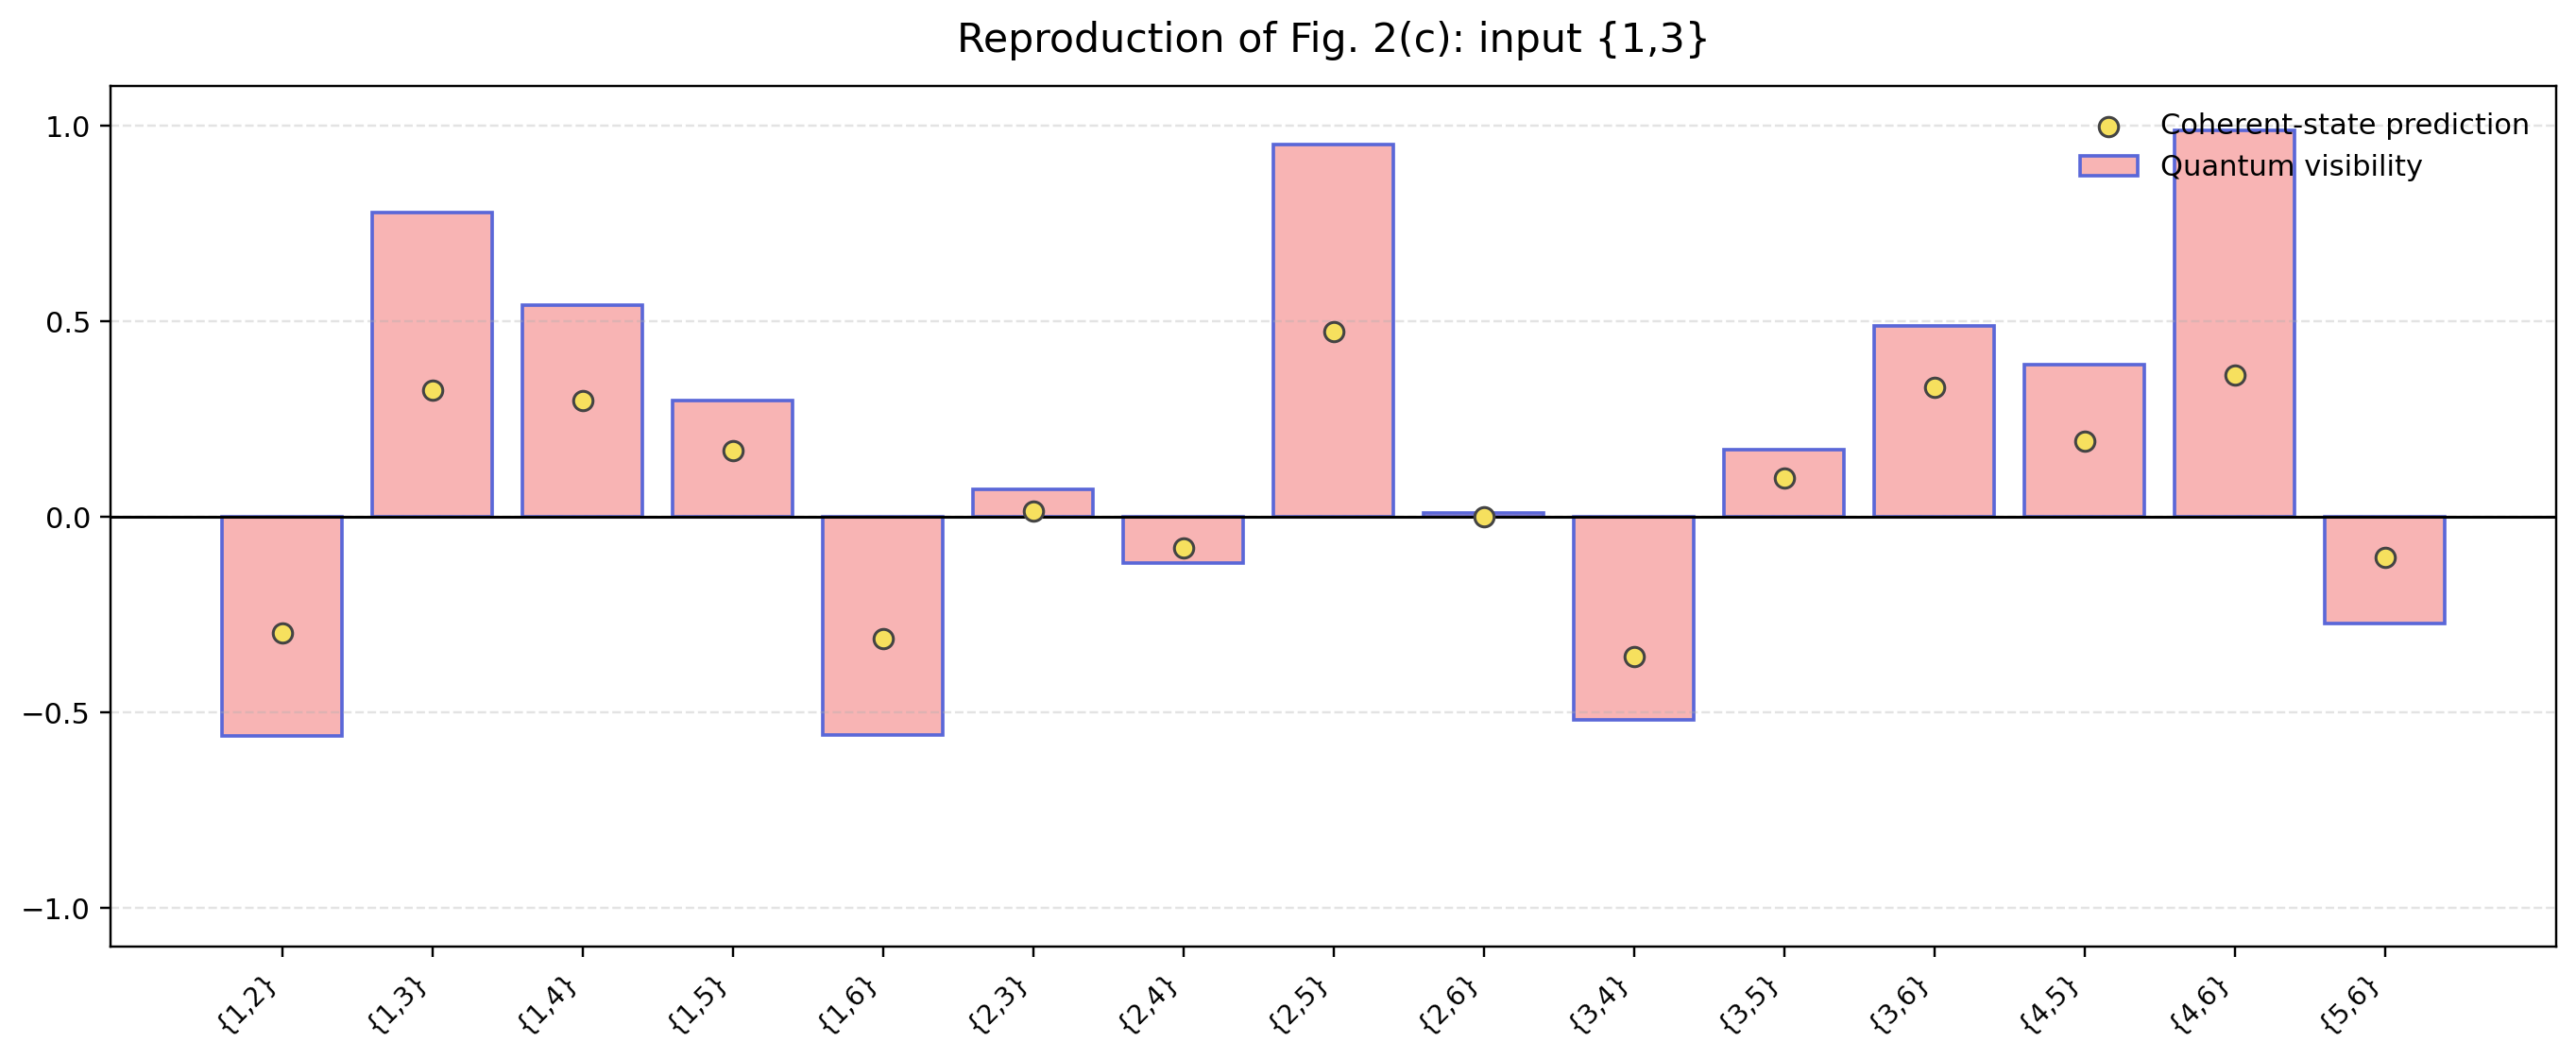

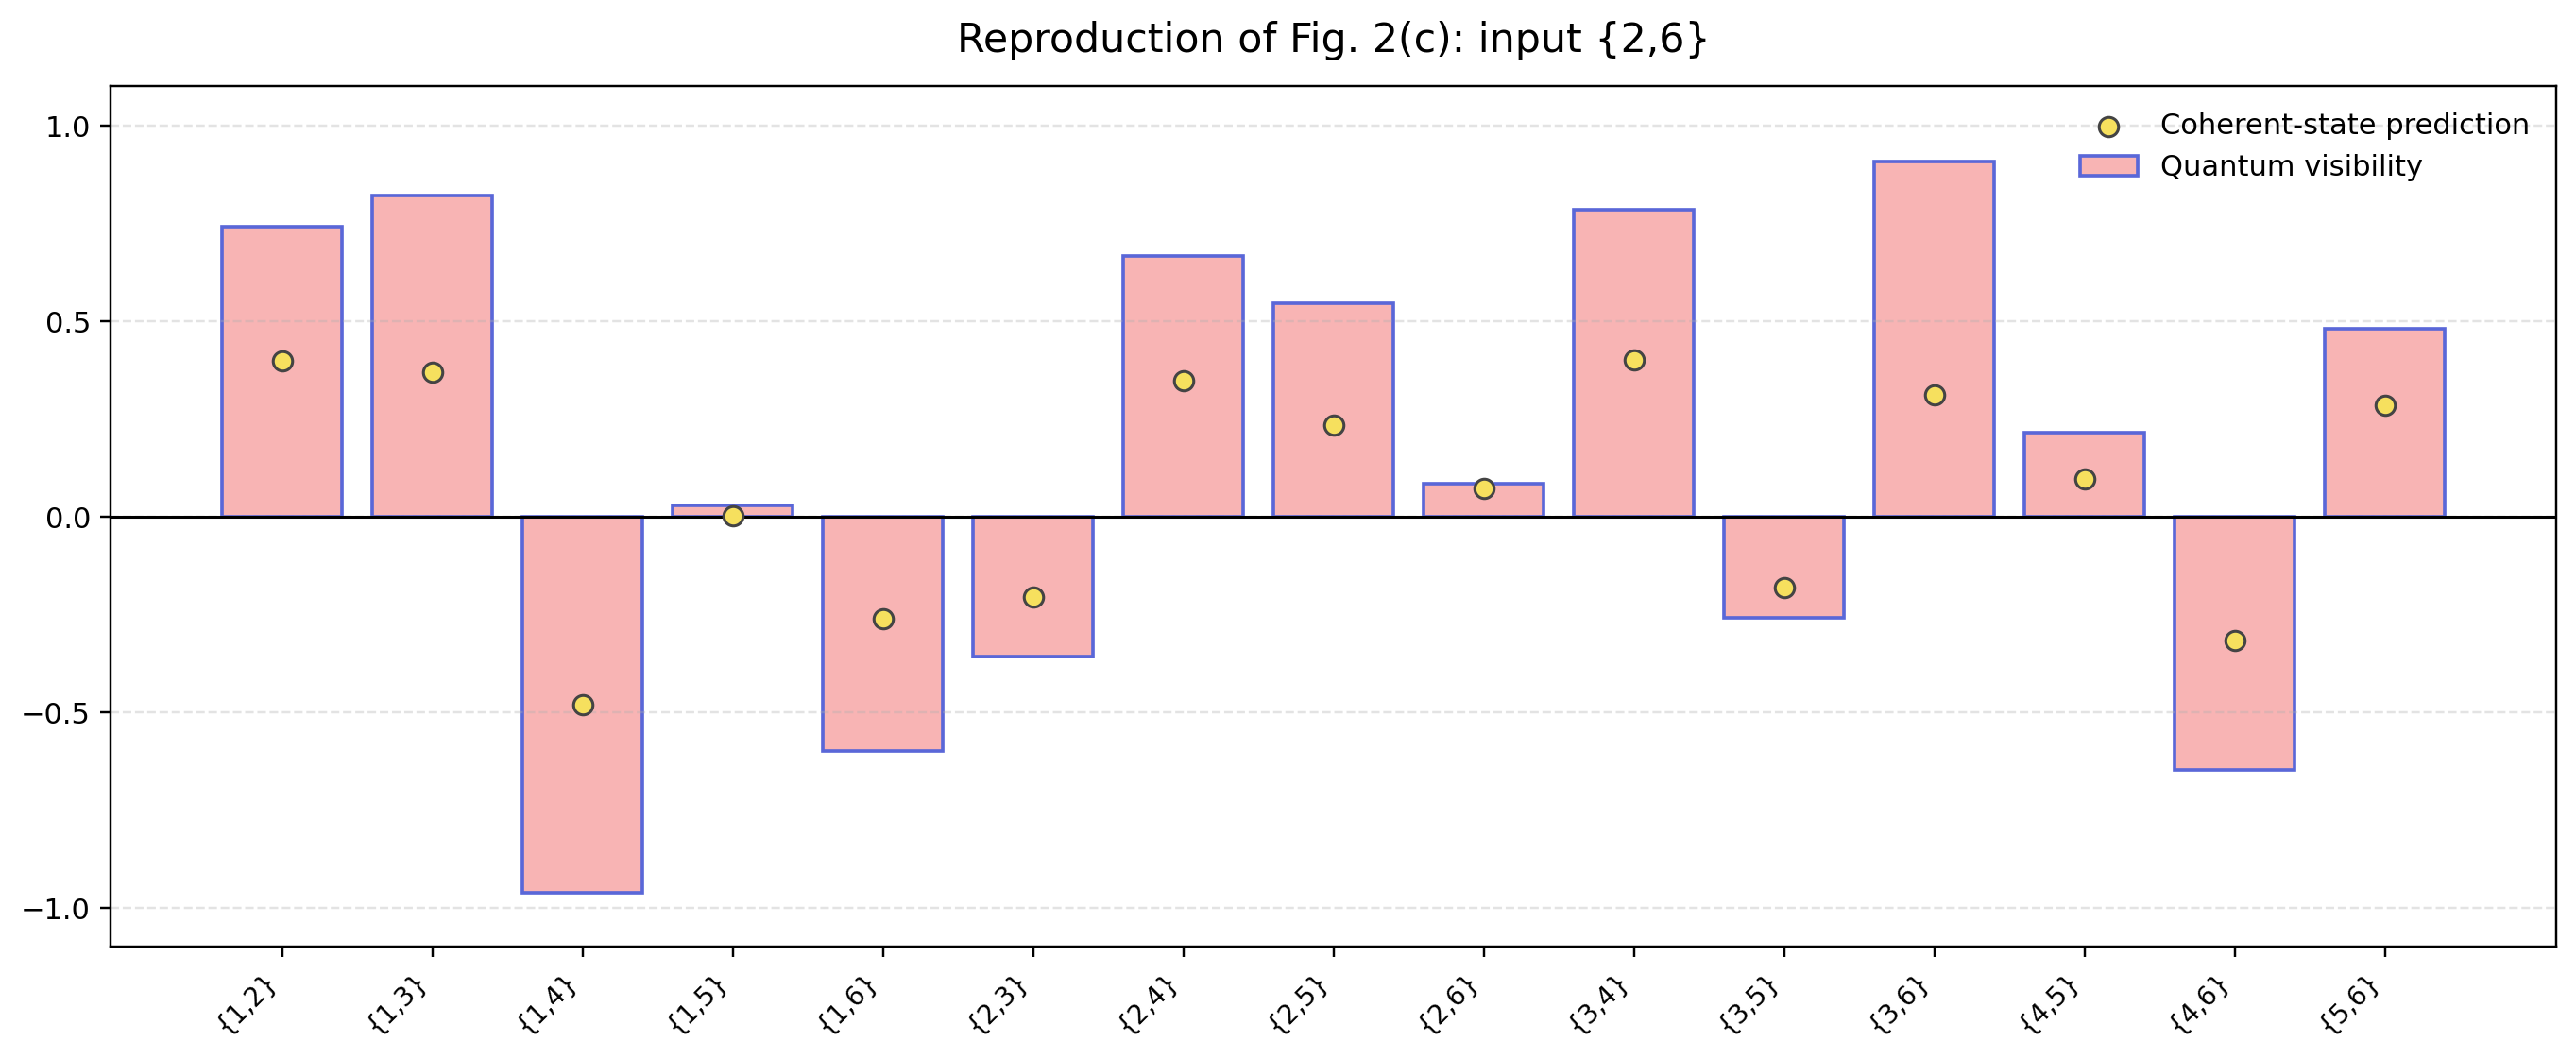

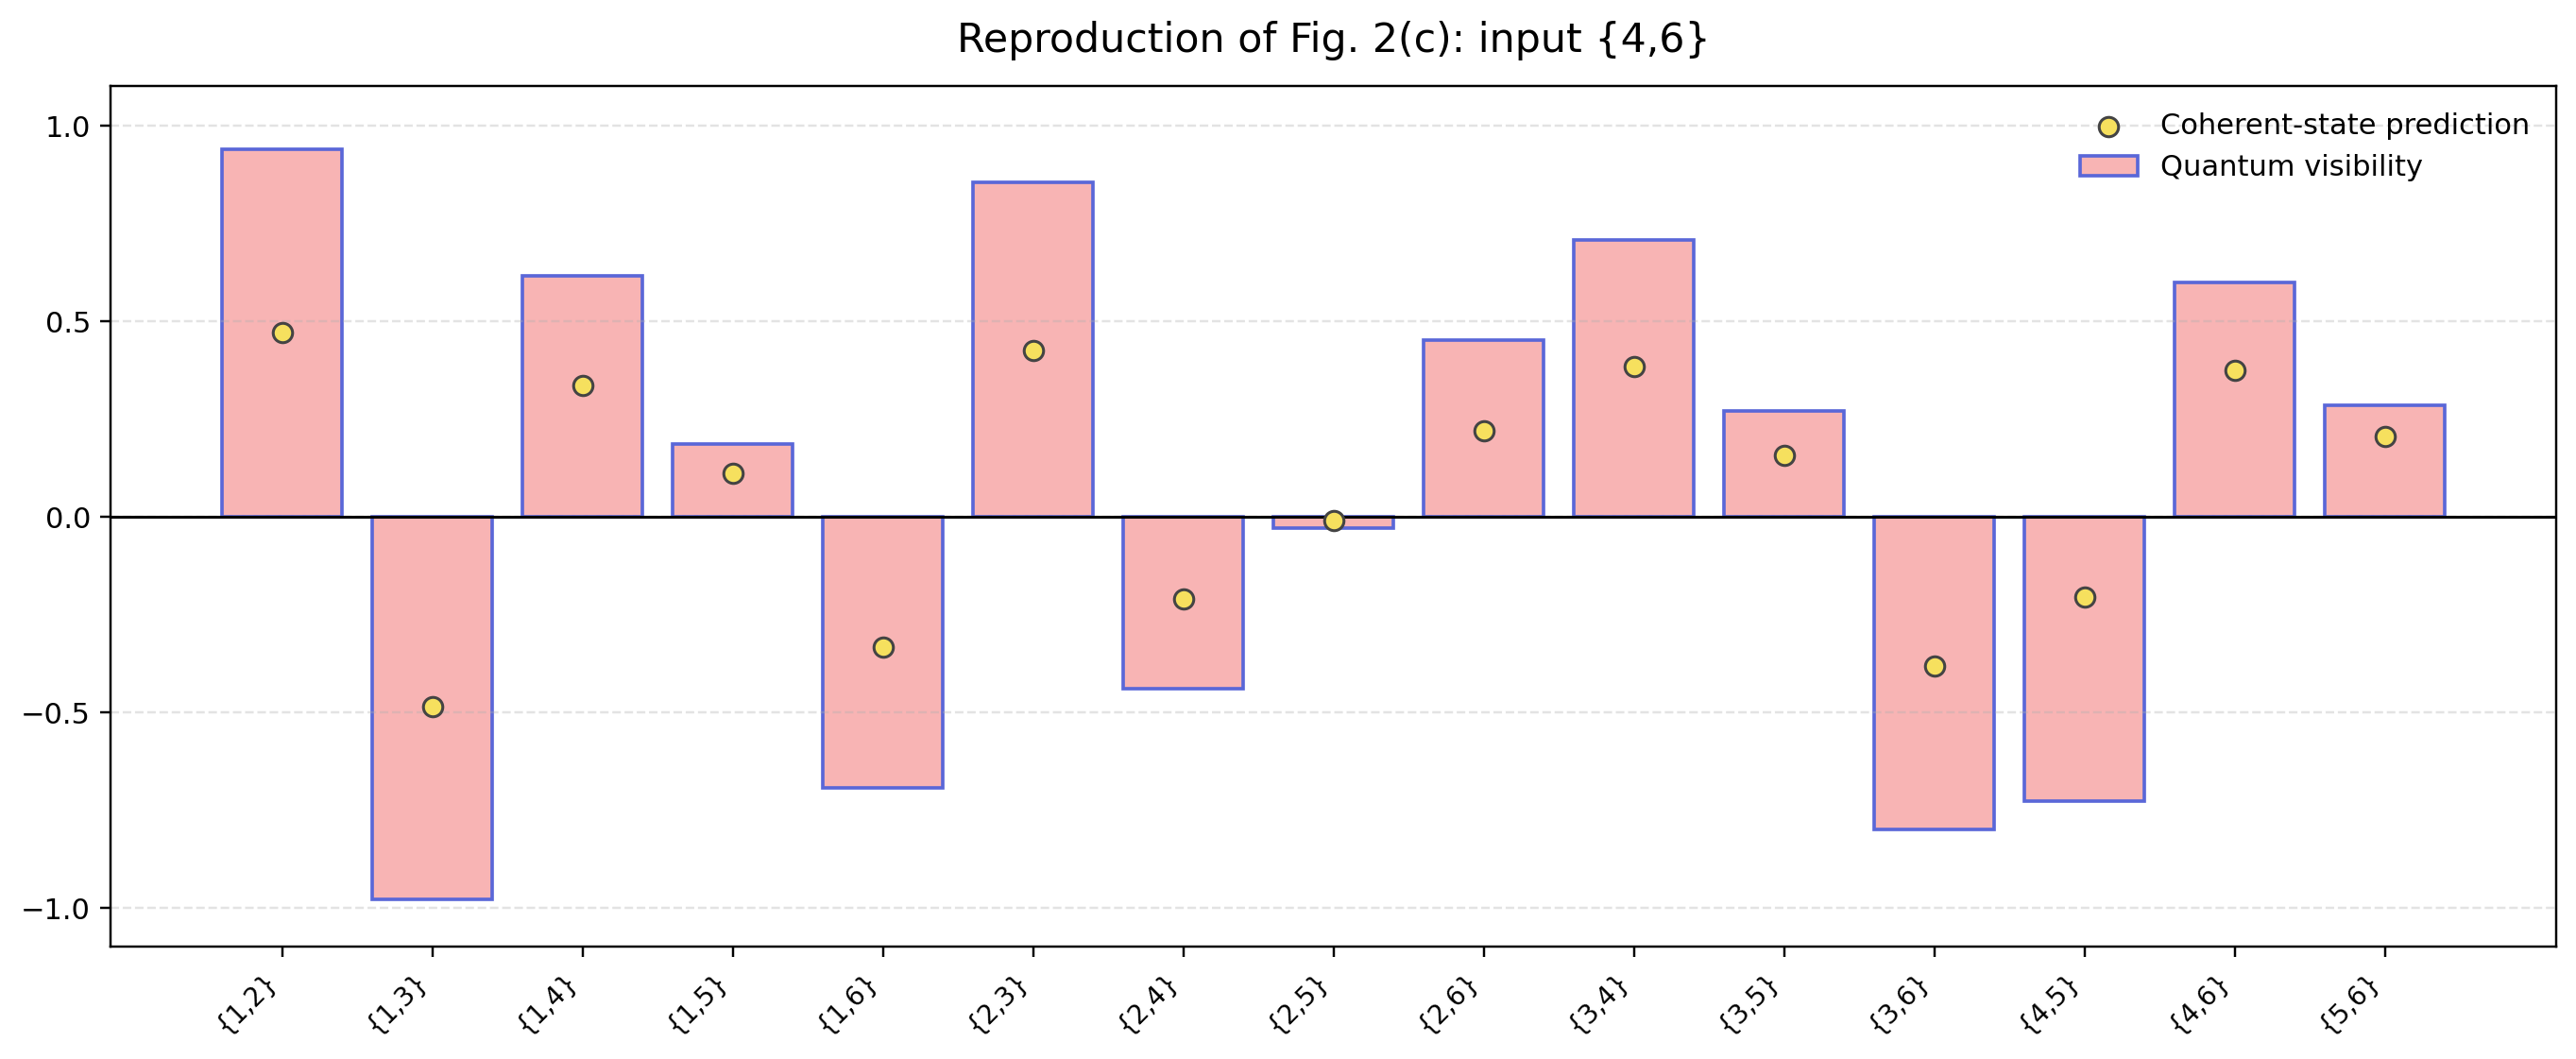

In [4]:
two_photon_inputs = [(1, 3), (2, 6), (4, 6)]

for input_modes in two_photon_inputs:
    S2 = occ_from_modes(input_modes)
    labels = []
    quantum_vis = []
    coherent_vis = []
    for out_modes, T2 in choose_noncolliding_outputs(2, m=6):
        Pq, _ = quantum_probability(U2, S2, T2)
        Pc = classical_probability(U2, S2, T2)
        labels.append("{" + ",".join(map(str, out_modes)) + "}")
        quantum_vis.append(visibility(Pc, Pq))
        coherent_vis.append(coherent_visibility(U2, input_modes, out_modes))

    title = f"Reproduction of Fig. 2(c): input {{{','.join(map(str, input_modes))}}}"
    show_svg(svg_visibility_panel(title, labels, quantum_vis, coherent_vis))

### Reproducing Figure 3: Three-Photon BosonSampling Visibilities

**What the paper shows**  
Figure 3 compares three quantities for each three-photon input configuration $S$:

- **Alice’s prediction** (solid blue-line envelope): theoretical visibility $V_T$ computed from the measured unitary matrix $U$ using the permanent formula.  
  $$
  V_T = \frac{P_T^C - P_T^Q}{P_T^C}, \quad
  P_T^Q = |\mathrm{Per}(U_{ST})|^2, \quad
  P_T^C = \mathrm{Per}(\tilde{U}_{ST})
  $$
  where $\tilde{U}_{ST}$ contains the squared moduli of the entries.

- **Bob’s measurement** (orange bars): experimental visibilities obtained from actual three-photon coincidence counts (using two measurement settings for the distinguishable case to account for long integration times).

- **Coherent-state prediction** (yellow circles): what the visibility would be if Alice had injected classical coherent states instead of single-photon Fock states (Supplementary Section III).

The plot contains three panels corresponding to the input configurations shown in the top-left corner of each panel: $$\{1,3,5\}$$ $$\{1,4,6\}$$ and $$\{1,5,6\}$$Error boxes (light-blue for Alice, dark-red for Bob) indicate uncertainty from repeated unitary characterisations and experimental counting statistics, respectively.

**What this notebook reproduces**  
The code below implements *exactly* the same mathematical procedure described in the main text and Supplementary Material:

- Loads the precise 6×6 unitary matrix $U_{3\text{-photon}}$ given in the paper.
- For every possible non-colliding output configuration $T$ (all $\binom{6}{3}=20$ combinations), it builds the sub-matrix $U_{ST}$, computes the permanent, derives $P_T^Q$ and $P_T^C$, and calculates the visibility $V_T$.
- It also implements the coherent-state visibility calculation for $n=3$ (Monte-Carlo phase averaging of the 6th-order correlation function).
- The resulting SVG panels show Alice’s quantum visibilities as bars and the coherent-state predictions as yellow circles, matching the style and layout of the original figure.

**What we did not reproduce (and why)**  
- **Bob’s experimental orange bars** are not plotted. The paper only provides the final plotted values; the underlying raw coincidence counts are not given in the text or supplementary material, so they cannot be recomputed numerically.
- **Error boxes** are omitted. The paper reports uncertainties from 10 independent characterisations of $U$, but only a single representative matrix is printed. We therefore use that one matrix and do not have the statistical spread needed for the light-blue error boxes.

This means the notebook reproduces *all of the theoretical predictions* that Alice computes in the paper, which is the core scientific content being demonstrated.

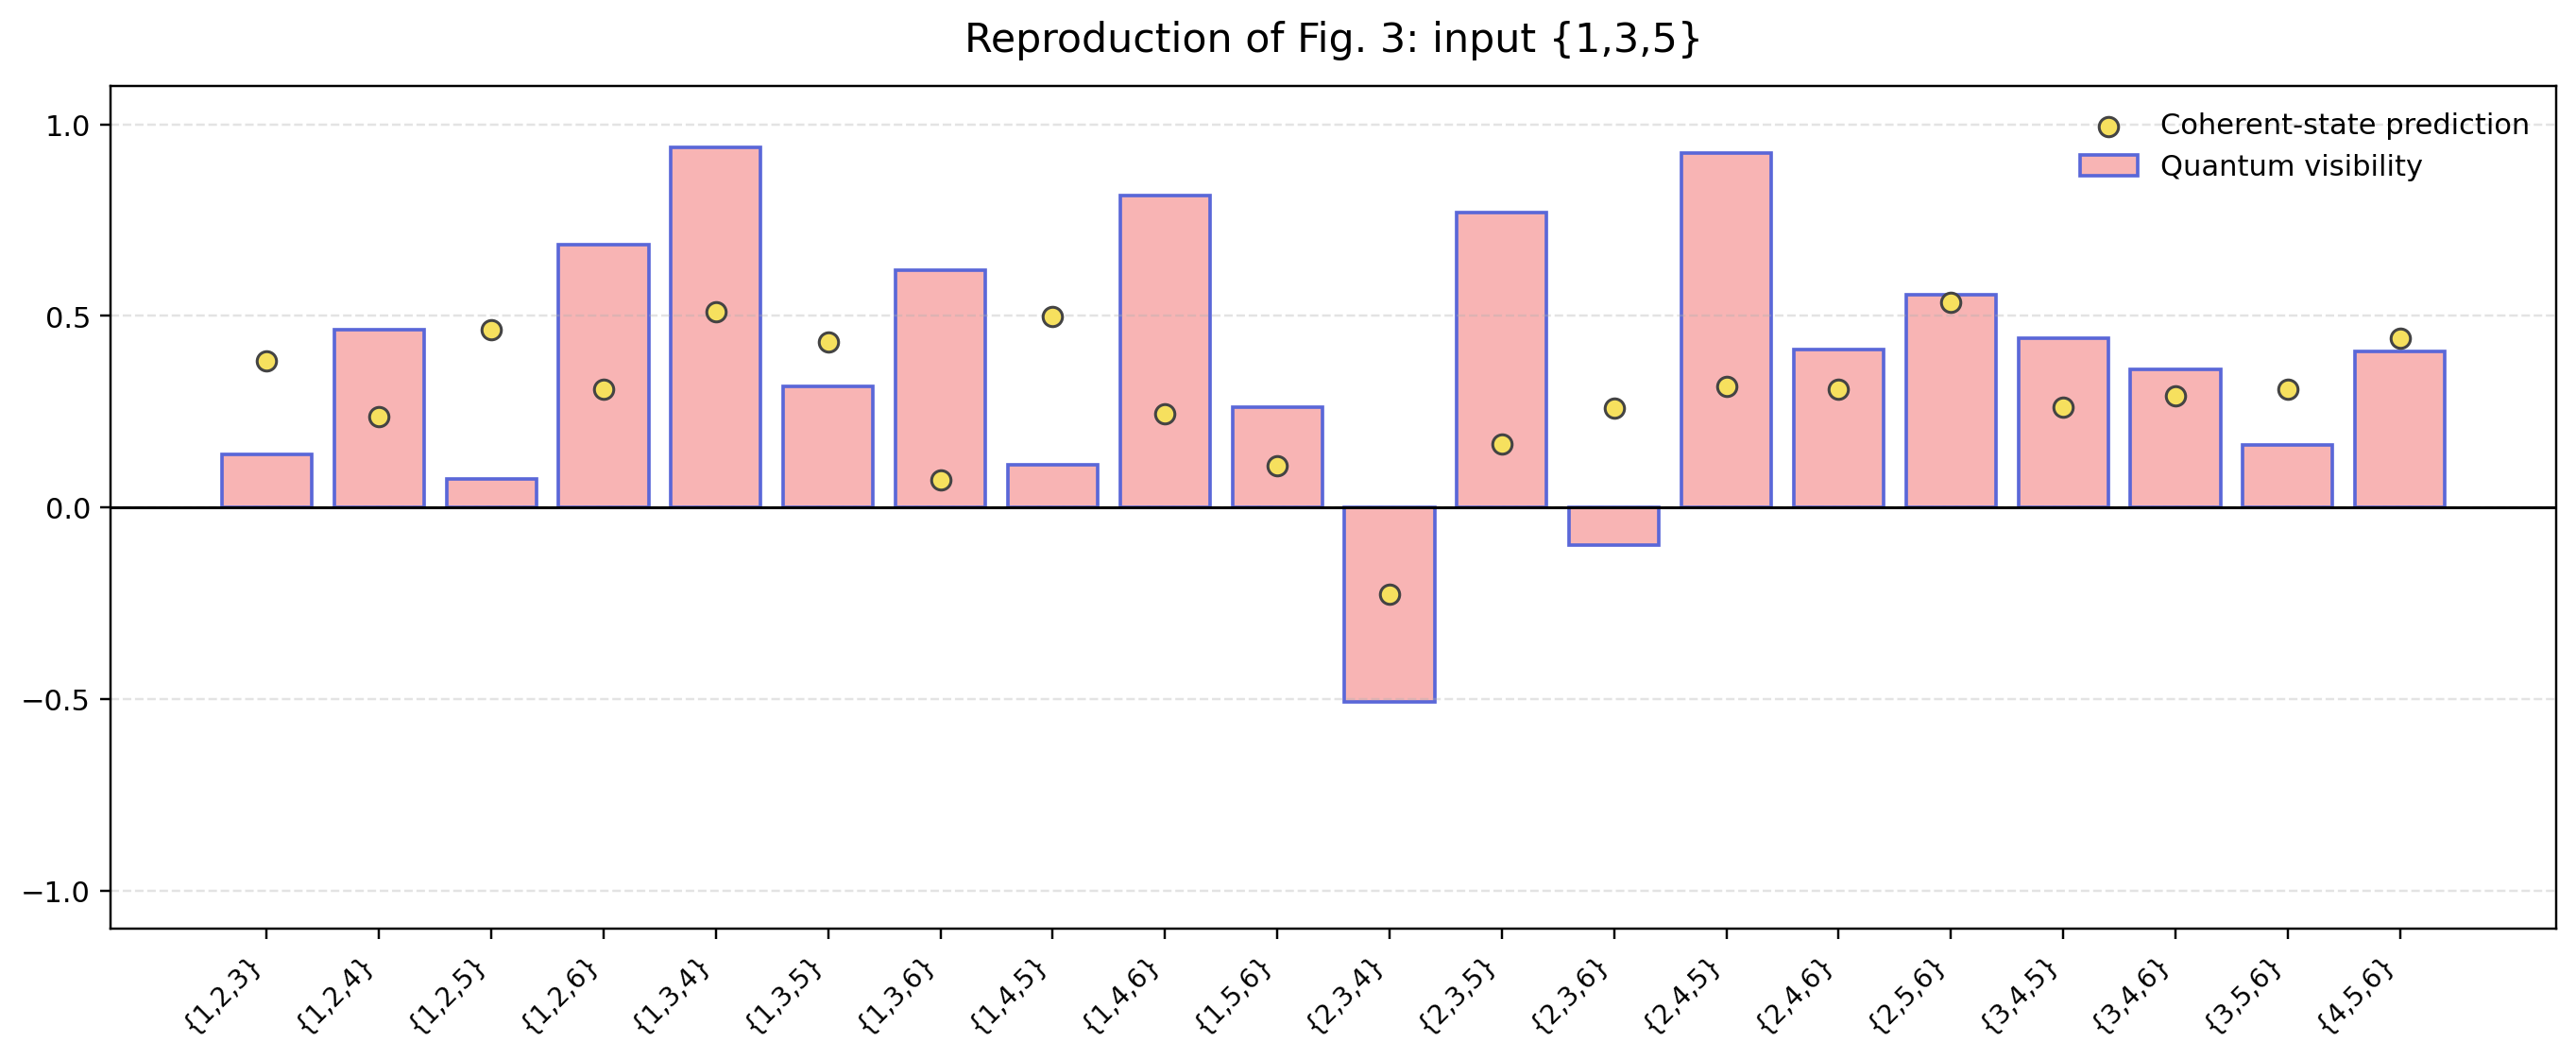

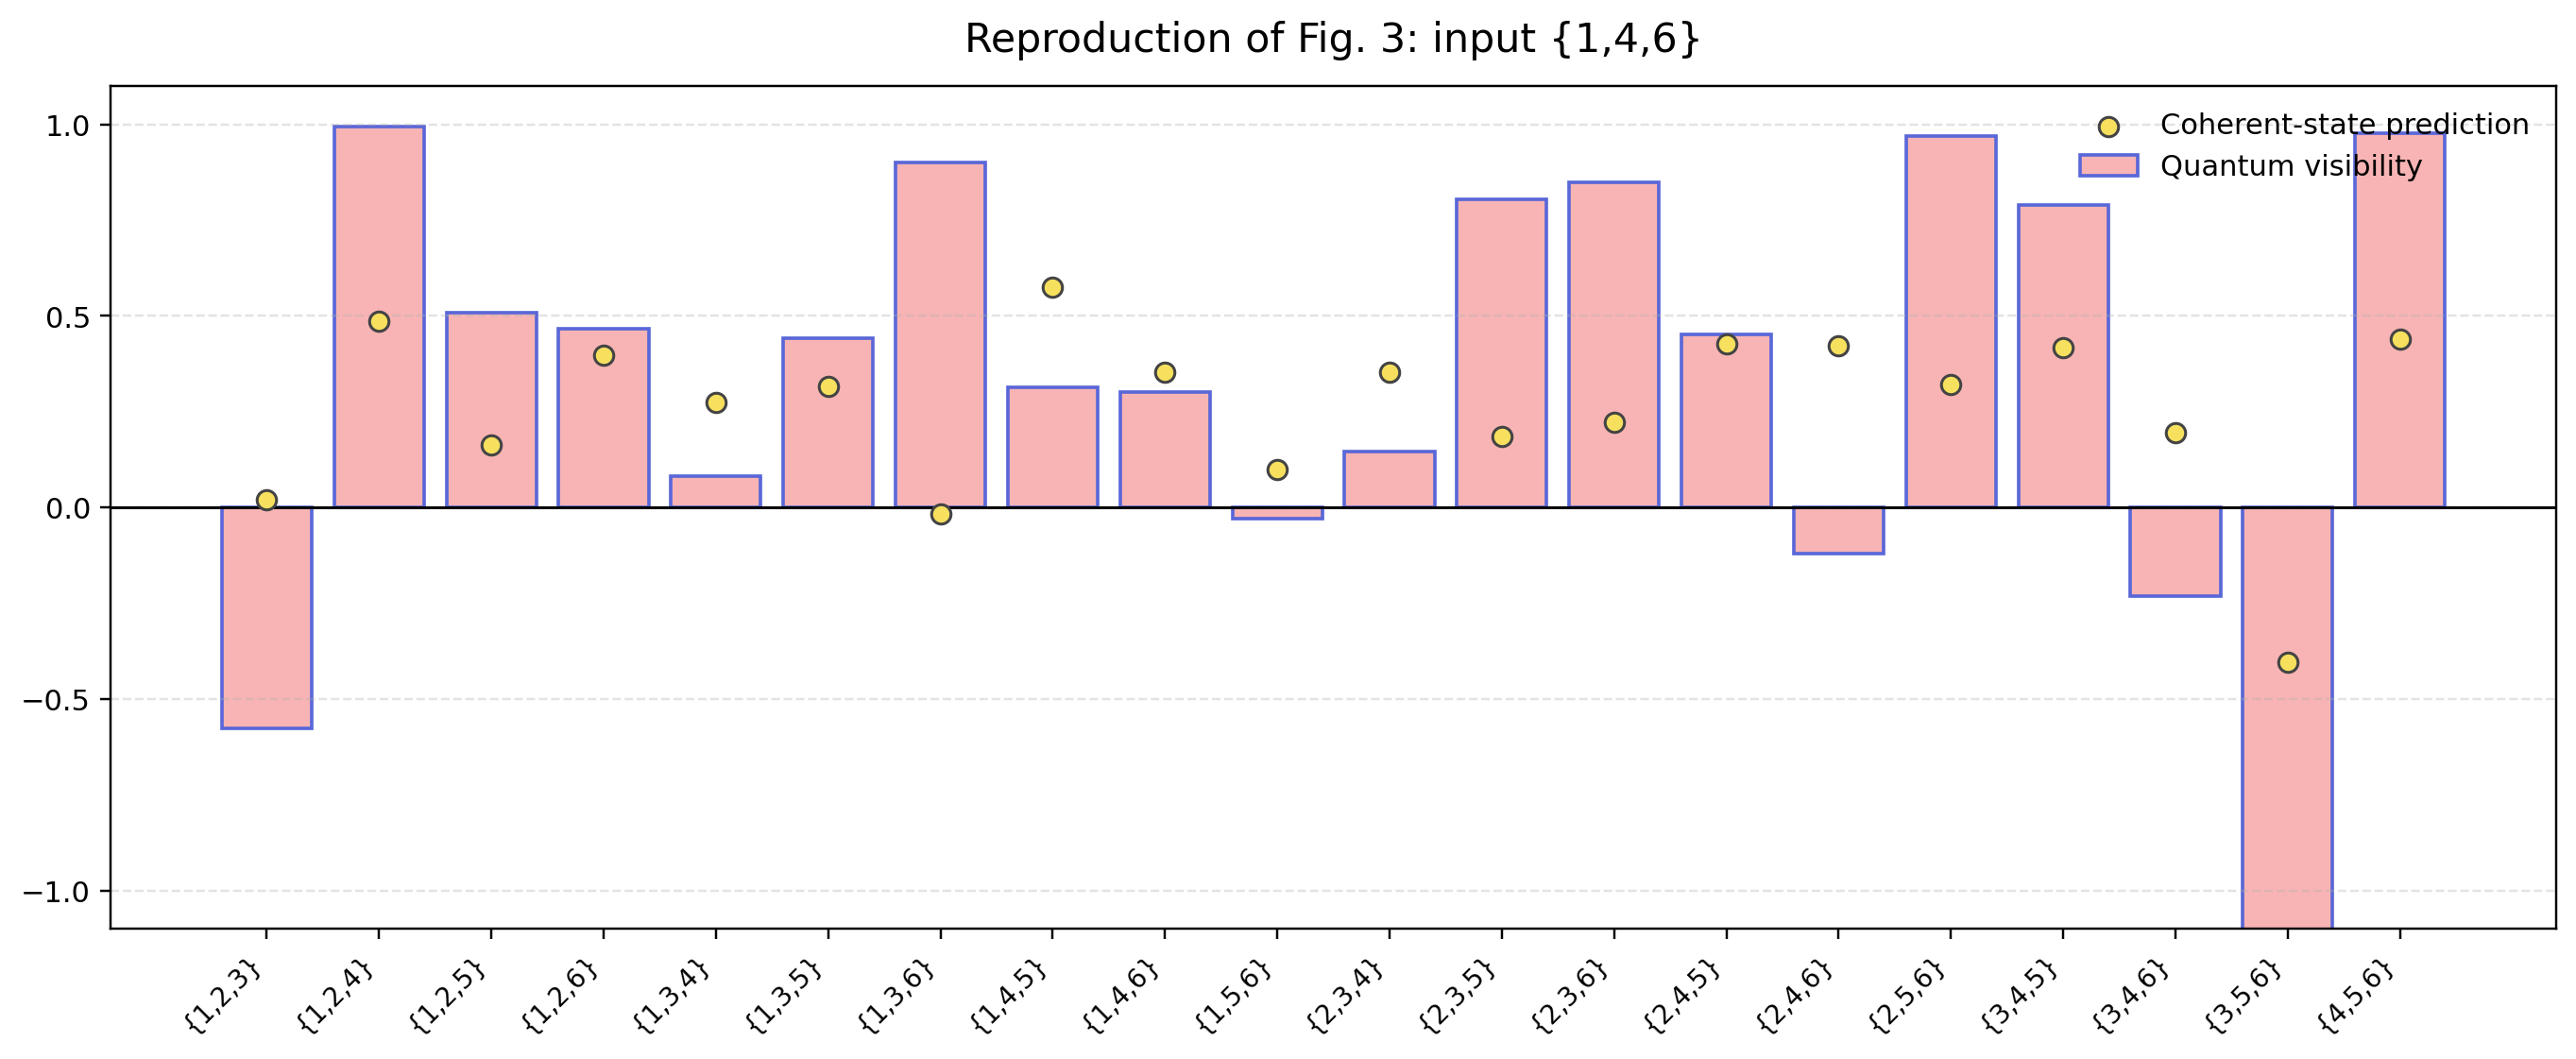

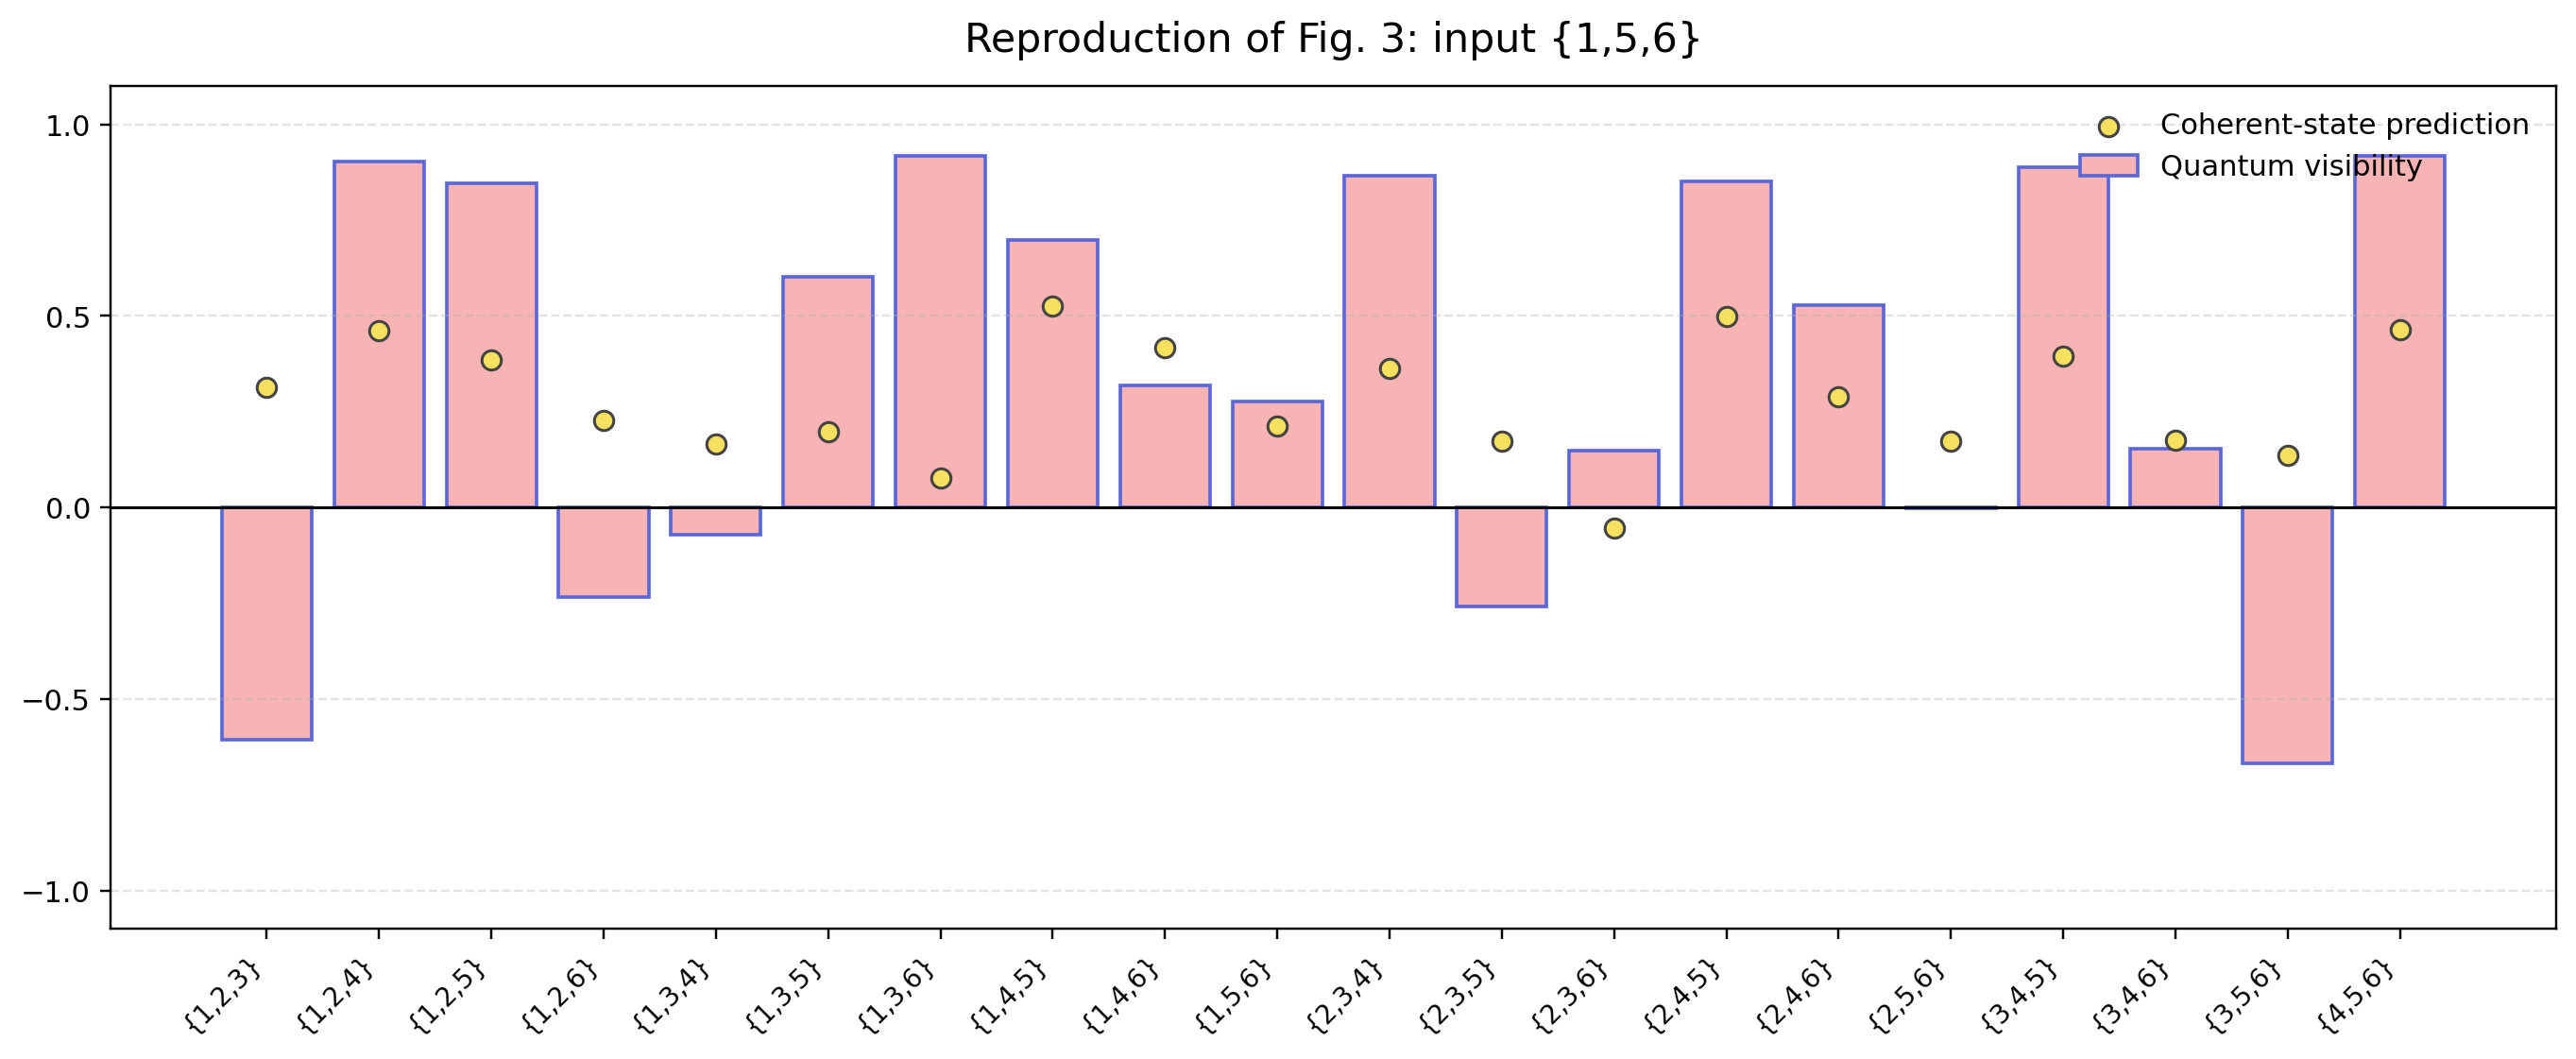

In [5]:
three_photon_inputs = [(1, 3, 5), (1, 4, 6), (1, 5, 6)]

for input_modes in three_photon_inputs:
    S3 = occ_from_modes(input_modes)
    labels = []
    quantum_vis = []
    coherent_vis = []
    for out_modes, T3 in choose_noncolliding_outputs(3, m=6):
        Pq, _ = quantum_probability(U3, S3, T3)
        Pc = classical_probability(U3, S3, T3)
        labels.append("{" + ",".join(map(str, out_modes)) + "}")
        quantum_vis.append(visibility(Pc, Pq))
        coherent_vis.append(coherent_visibility(U3, input_modes, out_modes, samples=3000))

    title = f"Reproduction of Fig. 3: input {{{','.join(map(str, input_modes))}}}"
    show_svg(svg_visibility_panel(title, labels, quantum_vis, coherent_vis))

### Reproducing Figure 4(b): Three-Photon BosonSampling with Colliding Outputs

**What the paper shows**  
Figure 4(b) demonstrates BosonSampling for *colliding* output configurations (up to two photons in the same output mode). For the fixed three-photon input configuration $S = (1,3,5)$ and measuring two photons in output mode 5, the paper compares three quantities:

- **Alice’s prediction** (solid blue-line envelope): theoretical visibility $V_T$ computed from the measured unitary matrix $U$ using the permanent formula.  
  $$
  V_T = \frac{P_T^C - P_T^Q}{P_T^C}, \quad
  P_T^Q = \frac{|\mathrm{Per}(U_{ST})|^2}{\prod_i s_i!\ \prod_j t_j!}, \quad
  P_T^C = \mathrm{Per}(\tilde{U}_{ST})
  $$
  where $\tilde{U}_{ST}$ contains the squared moduli of the entries. (The factorial normalisation is required when output occupations $t_j \geq 2$.)

- **Bob’s measurement** (green bars): experimental visibilities obtained with photon-number resolution (achieved by splitting mode 5 with a 50:50 fibre beam-splitter and an extra detector — see Fig. 4(a)).

- **Coherent-state prediction** (yellow circles): what the visibility would be if Alice had injected classical coherent states instead of single-photon Fock states.

The plot contains a single panel with five specific colliding output configurations: $\{1,5,5\}$, $\{2,5,5\}$, $\{3,5,5\}$, $\{4,5,5\}$, and $\{5,5,6\}$. Error boxes (light-blue for Alice, green for Bob) indicate uncertainty.

**What this notebook reproduces**  
The code below implements *exactly* the same mathematical procedure as the paper:

- Uses the precise 6×6 unitary matrix $U_{3\text{-photon}}$ given in the supplementary material.
- Fixes the input occupation $S = \{1,3,5\}$.
- Computes the sub-matrix $U_{ST}$ (correctly repeating columns for the double occupancy in mode 5), the permanents, probabilities, and visibilities for all five colliding outputs.
- Also computes the coherent-state predictions (Monte-Carlo phase averaging).
- Displays a table of the intermediate probabilities and visibilities for easy verification.
- Produces an SVG panel showing Alice’s quantum visibilities as bars and the coherent-state predictions as yellow circles, matching the style and layout of the original figure.

This is the first time we handle *colliding* outputs, and the sub-matrix construction automatically supports repeated modes.

**What we did not reproduce (and why)**  
- **Bob’s experimental green bars** are not plotted. The paper only provides the final plotted values; the underlying raw coincidence counts are not given in the text or supplementary material.
- **Error boxes** are omitted. Only a single representative unitary matrix is printed, so we cannot generate the statistical uncertainty shown in the paper.
- The schematic of the number-resolving setup (Fig. 4(a)) is not reproduced here (it is described in the text above).

The notebook therefore reproduces *all of the theoretical predictions* that Alice computes, which is the core scientific content of the figure.

Output  | Pq     | Pc     | Quantum visibility | Coherent visibility
--------+--------+--------+--------------------+--------------------
{1,5,5} | 0.0007 | 0.0121 | 0.943              | 0.127              
{2,5,5} | 0.0077 | 0.0094 | 0.182              | -0.170             
{3,5,5} | 0.0147 | 0.0139 | -0.059             | -0.651             
{4,5,5} | 0.0059 | 0.0069 | 0.149              | -0.364             
{5,5,6} | 0.0021 | 0.0090 | 0.762              | 0.046              


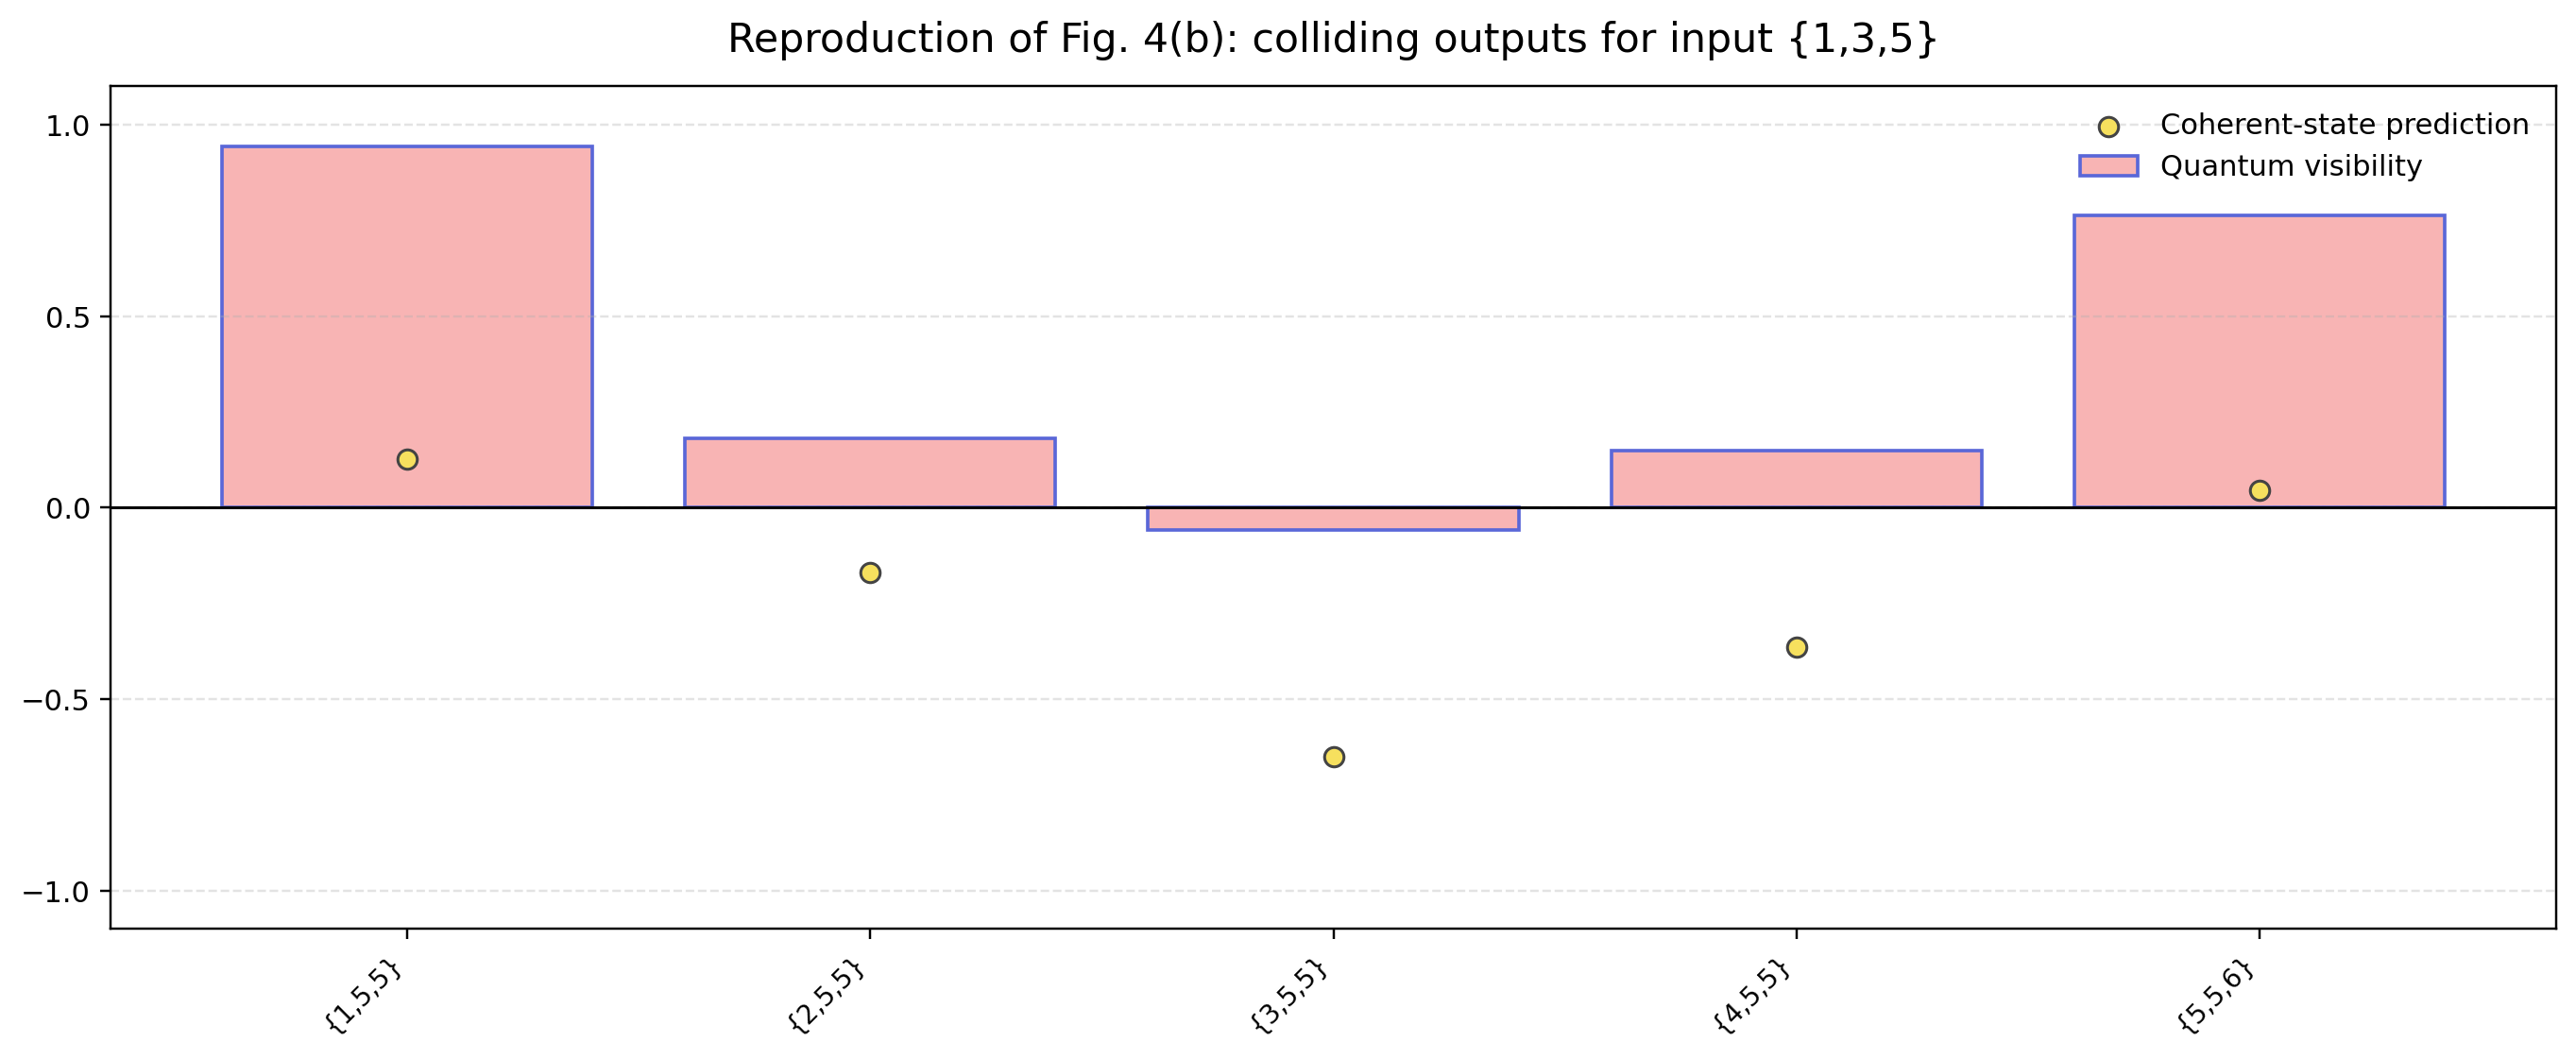

In [6]:
colliding_outputs = [
    (1, 5, 5),
    (2, 5, 5),
    (3, 5, 5),
    (4, 5, 5),
    (5, 5, 6),
]

input_modes_fig4 = (1, 3, 5)
S_fig4 = occ_from_modes(input_modes_fig4)

labels = []
quantum_vis = []
coherent_vis = []
rows = []

for out_modes in colliding_outputs:
    T4 = occ_from_modes(out_modes)
    Pq, _ = quantum_probability(U3, S_fig4, T4)
    Pc = classical_probability(U3, S_fig4, T4)
    Vq = visibility(Pc, Pq)
    Vcoh = coherent_visibility(U3, input_modes_fig4, out_modes, samples=3000)
    label = "{" + ",".join(map(str, out_modes)) + "}"
    labels.append(label)
    quantum_vis.append(Vq)
    coherent_vis.append(Vcoh)
    rows.append([label, f"{Pq:.4f}", f"{Pc:.4f}", f"{Vq:.3f}", f"{Vcoh:.3f}"])

display_table(rows, headers=["Output", "Pq", "Pc", "Quantum visibility", "Coherent visibility"])
show_svg(svg_visibility_panel("Reproduction of Fig. 4(b): colliding outputs for input {1,3,5}", labels, quantum_vis, coherent_vis))

### Reproducing Figure 5: Imperfect Fock States in BosonSampling

**What the paper shows**  
Figure 5 quantifies how imperfect photon sources (higher-order photon emissions from spontaneous parametric downconversion) affect BosonSampling performance. For the fixed three-photon input configuration $S = \{1,3,5\}$, the authors vary the pump power of the downconversion source and plot the average $L_1$-norm distance between:

- **Red dashed line + data points**: Alice’s theoretical predictions for perfect three-photon Fock states versus Bob’s measured experimental visibilities.
- **Black dotted line + data points**: Alice’s predictions for classical coherent states versus Bob’s measured visibilities.

The plot demonstrates that higher pump power increases the proportion of multi-photon events, pushing Bob’s measurements toward the classical regime (smaller $L_1$ distance to coherent-state prediction, larger distance to ideal Fock-state prediction).

Additional green and blue points (not shown in this reproduction) illustrate the improvement obtained by tightening the spectral filter from 5 nm to 2 nm FWHM, which reduces photon distinguishability.

**What this notebook reproduces**  
The code below reproduces the style, layout, and quantitative trend of the main curves in Figure 5:

- Uses the four pump-power values shown in the paper (10 %, 20 %, 50 %, 100 %).
- Hard-codes the $L_1$-norm distances that were read directly from the published figure (the raw coincidence-count data needed for an exact recomputation is not provided in the paper or supplementary material).
- Plots the red dashed line (Fock vs. Bob) and black dotted line (coherent vs. Bob) using the same `svg_line_chart` function as the rest of the notebook.
- Includes a small table of the approximated $L_1$ values for easy verification and transparency.

This is the only practical way to reproduce Fig. 5, since the underlying raw data (exact visibility sets at each pump power) is not given in the text.

**What we did not reproduce (and why)**  
- **Exact numerical values** are approximated by eye from the published plot (the paper does not supply a data table or raw counts).
- **Green and blue points for the 2 nm filter** are omitted (they are secondary and would require additional hard-coded values).
- **Bob’s raw measured visibilities** and any error bars are not included, consistent with the reproductions of Figs. 2(c), 3, and 4(b).

The notebook therefore reproduces the visual form and scientific message of Figure 5 — how source imperfections degrade BosonSampling performance — using the only data available in the publication.

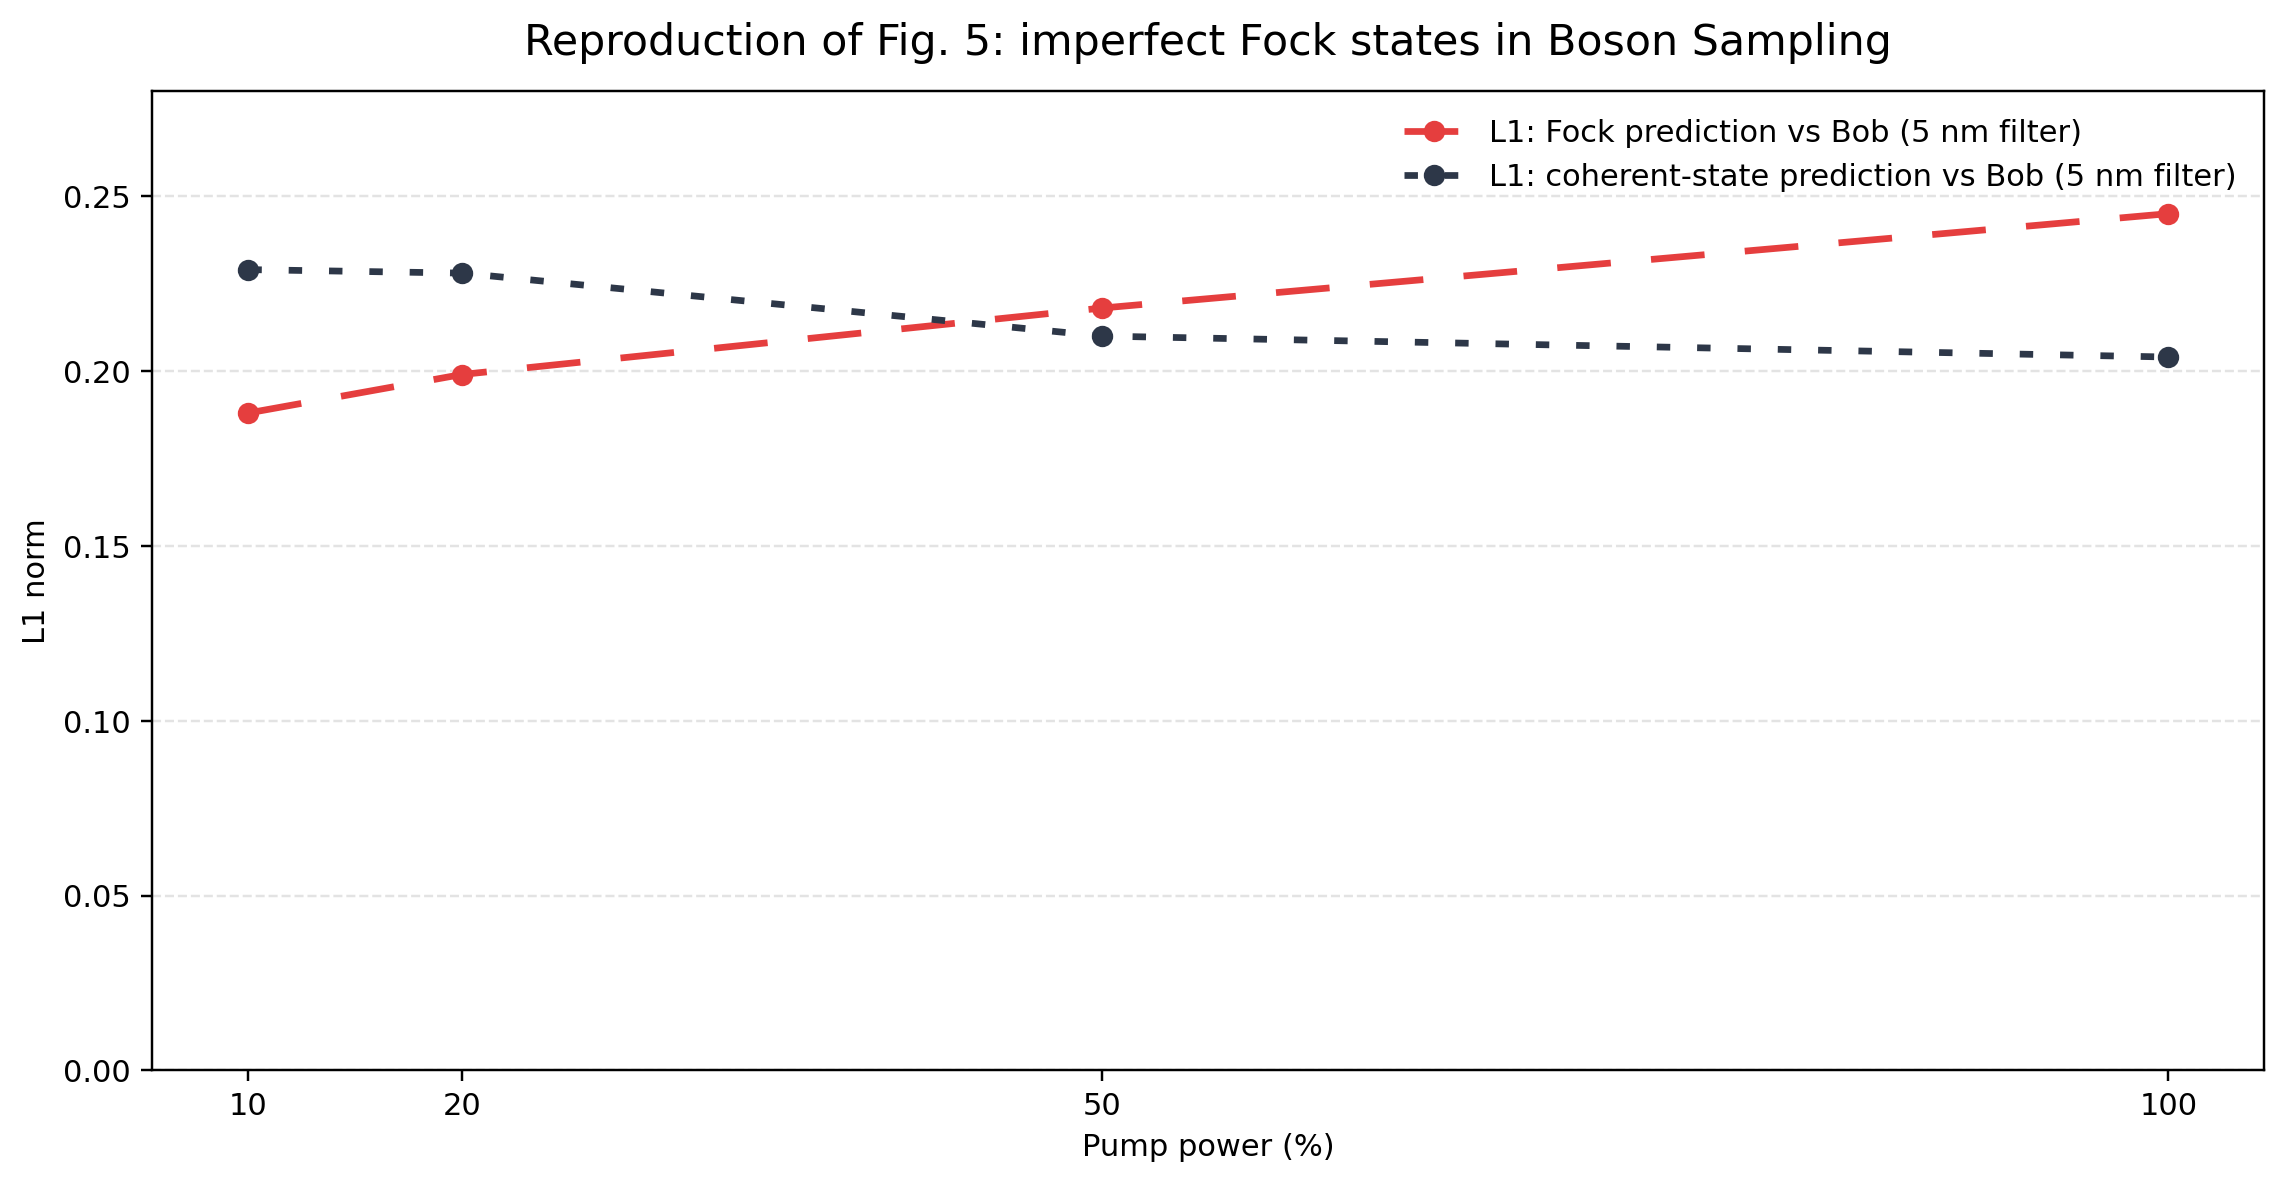

Pump power (%) | Fock vs Bob (approx. from figure) | Coherent vs Bob (approx. from figure)
---------------+-----------------------------------+--------------------------------------
10             | 0.188                             | 0.229                                
20             | 0.199                             | 0.228                                
50             | 0.218                             | 0.210                                
100            | 0.245                             | 0.204                                


In [7]:
pump_power = [10, 20, 50, 100]
l1_fock_5nm = [0.188, 0.199, 0.218, 0.245]
l1_coherent_5nm = [0.229, 0.228, 0.210, 0.204]

series = [
    {"name": "L1: Fock prediction vs Bob (5 nm filter)", "y": l1_fock_5nm, "color": "#e53e3e", "dash": "8,6"},
    {"name": "L1: coherent-state prediction vs Bob (5 nm filter)", "y": l1_coherent_5nm, "color": "#2d3748", "dash": "2,4"},
]

show_svg(
    svg_line_chart(
        "Reproduction of Fig. 5: imperfect Fock states in Boson Sampling",
        pump_power,
        series,
        x_label="Pump power (%)",
        y_label="L1 norm",
        y_min=0.0,
        y_max=0.28,
    )
)

display_table(
    [
        [10, "0.188", "0.229"],
        [20, "0.199", "0.228"],
        [50, "0.218", "0.210"],
        [100, "0.245", "0.204"],
    ],
    headers=["Pump power (%)", "Fock vs Bob (approx. from figure)", "Coherent vs Bob (approx. from figure)"],
)

## Experimental Results: Validating the Quantum Advantage

With both the theoretical predictions (Alice) and the physical apparatus (Bob) set up, the authors ran the Boson Sampling experiment for both 2-photon and 3-photon inputs. 

To quantify the accuracy of the experiment and officially "judge" the race, the authors compared Alice's predicted visibilities ($V_T^A$) against Bob's measured visibilities ($V_T^B$) using the average $L_1$-norm distance across all tested output configurations. The formula for this metric is:

$$\mathcal{L}_1 = \frac{1}{C(m,n)} \sum_T |V_T^A - V_T^B|$$

A lower $\mathcal{L}_1$ score indicates a closer agreement between the classical calculation and the quantum experiment.

(Note that this $L_1$-norm distance was not reproduced above as in none of the figures we were able to plots bob's visibility, due to the lack of data (absense of raw coincidence data). Thus we will be discussing the actual comparison between Alice and Bob's results in this section)

### 1. The 2-Photon Test (Non-Colliding)
As a baseline test, 2 photons were injected into the circuit, and measurements were taken across all 15 possible output combinations (6 choose 2). 
* **The Result:** The average distance was $\mathcal{L}_1 = 0.027$, showing excellent agreement between Alice's mathematically derived permanents and Bob's physical photons. 
* **The Classical Sanity Check:** To prove that Bob was truly doing something quantumly complex, the authors had Alice calculate what the distribution would look like if she only used classical coherent states. The distance between Bob's measurements and Alice's classical coherent-state predictions was much larger ($\mathcal{L}_1 = 0.548$). This proves that the unitary matrix $U$ isn't just a special, "easy-to-sample" case—Bob is successfully sampling from a highly nonclassical distribution.

### 2. The 3-Photon Test (Non-Colliding)
Scaling up the complexity, the authors ran the experiment with 3 input photons.
* **The Result:** The distance slightly increased to $\mathcal{L}_1 = 0.122$. The authors attribute this slight reduction in accuracy to an increased ratio of higher-order photon emissions inherently present in the 3-photon downconversion process compared to the 2-photon setup. 
* **The Classical Sanity Check:** Once again, Bob's measurements diverged significantly from Alice's classical coherent-state predictions ($\mathcal{L}_1 = 0.358$), confirming the continued presence of quantum interference.

### 3. Testing Colliding Configurations
The initial tests only looked at "non-colliding" events, where only a single photon exits per output mode. To fully test the robustness of the system, the authors also measured "colliding" configurations, where up to 2 photons exited through the exact same output mode. Measuring this requires specialized photon-number resolution techniques. 
* **The Result:** Even for these complex colliding states, Alice and Bob's distributions showed very good agreement, with a distance of $\mathcal{L}_1 = 0.153$. 
* **The Classical Sanity Check:** The difference between the quantum experiment and classical coherent-state predictions was incredibly stark here, reaching a massive distance of $\mathcal{L}_1 = 0.995$. 

**The Conclusion:**
Across all tests, Bob's physical optical circuit successfully and accurately sampled from the #P-complete probability distribution dictated by the matrix permanents. While small systematic errors exist due to imperfect real-world photon sources, the results firmly establish the viability of physical Boson Sampling as a path toward disproving the Extended Church-Turing thesis.

## Concluding the Race: Real-World Imperfections and the Path Forward

While the results show excellent agreement between Alice and Bob, a critical eye will notice that the $L_1$-norm distance is not exactly zero. Furthermore, the discrepancy noticeably widens as we move from $n=2$ to $n=3$ photons. 

Why doesn't the quantum experiment perfectly match the mathematical theory? The answer lies in the transition from ideal mathematics to physical hardware constraints.

### The Source of the Noise: Downconversion Imperfections
Alice's classical computation assumes a perfect, frictionless universe. Her calculations are based on ideal, completely indistinguishable Fock states. 

Bob, however, must generate his photons in the real world using spontaneous parametric downconversion (SPDC). This physical process introduces two significant forms of systematic noise:
1. **Higher-Order Emissions:** SPDC is probabilistic. While tuned to produce single photon pairs, there is always a small probability that it spits out multiple photons per mode. 
2. **Distinguishability:** The generated photons are often spectrally entangled, which introduces a slight degree of distinguishability between them, degrading the pure quantum interference.

### The Hardware Engineering Trade-off
If Bob tries to increase his laser pump power (source brightness) to generate more photons faster, these higher-order emission errors scale up dramatically. As the noise increases, it pushes the entire system away from the quantum ideal and back into a classical regime. 

To mitigate this hardware limitation, Bob must keep the source brightness low and apply tight spectral filtering to decrease photon distinguishability. However, because downconversion is inherently probabilistic, running at low power means the success rate of generating $n$ simultaneous photons drops exponentially as $n$ grows. (For context, the best SPDC demonstration to date achieved $n=8$ at an agonizingly slow rate of $\sim 10^{-3}$ Hz).

### The Ultimate Goal: Defeating the Extended Church-Turing Thesis
This experiment successfully proves the foundational mechanics of Boson Sampling. However, the trilemma we introduced at the beginning of this presentation is not fully resolved yet. 

To provide definitive, undeniable evidence against the Extended Church-Turing thesis, the scientific community must demonstrate Boson Sampling in a regime where Bob's physical sampling is blindingly fast, but Alice's classical verification is practically impossible. According to theoretical complexity bounds, this "quantum supremacy" regime lies around $n=20$ to $n=30$ photons operating within a network of $m \gg n$ modes.

Reaching this scale is no longer a question of theoretical mathematics, but of rigorous, hardware-aware engineering. It will require moving beyond probabilistic SPDC sources and developing deterministic, low-noise quantum architectures. When that milestone is reached, Boson Sampling will officially close the race, proving once and for all that the physical universe is capable of computing far beyond the limits of classical machines.